<a href="https://colab.research.google.com/github/eisbetterthanpi/ssm/blob/main/hippo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

f1 torch.Size([100, 2])
fwd torch.Size([100, 256, 256]) torch.Size([100, 2, 256])
fwd torch.Size([100, 2, 256])
reconstruct torch.Size([100, 256]) torch.Size([2, 256])
f_legs1 torch.Size([100, 2])
f_legs2 torch.Size([200, 1])
f f_legs torch.Size([100, 2]) torch.Size([200, 1])


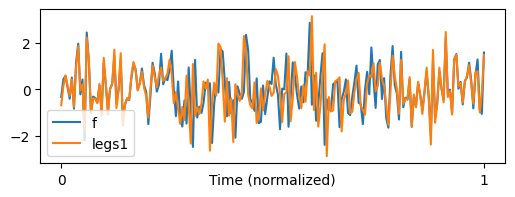

In [ ]:
# @title hippo.py down
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
# from scipy import signal
from scipy import linalg as la
from scipy import special as ss


# https://github.com/HazyResearch/hippo-code/blob/master/model/unroll.py
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def batch_mult(A, u, has_batch=None):
    """ Matrix mult A @ u with special case to save memory if u has additional batch dim
    The batch dimension is assumed to be the second dimension
    A : (L, ..., N, N)
    u : (L, [B], ..., N)
    has_batch: True, False, or None. If None, determined automatically
    Output:
    x : (L, [B], ..., N)
      A @ u broadcasted appropriately
    """
    if has_batch is None: has_batch = len(u.shape) >= len(A.shape)
    if has_batch: u = u.permute([0] + list(range(2, len(u.shape))) + [1])
    else: u = u.unsqueeze(-1)
    v = (A @ u)
    if has_batch: v = v.permute([0] + [len(u.shape)-1] + list(range(1, len(u.shape)-1)))
    else: v = v[..., 0]
    return v


def variable_unroll_general_sequential(A, u, s, op, variable=True):
    """ Unroll with variable (in time/length) transitions A with general associative operation
    A : ([L], ..., N, N) dimension L should exist iff variable is True
    u : (L, [B], ..., N) updates
    s : ([B], ..., N) start state
    output : x (..., N)
    x[i, ...] = A[i]..A[0] s + A[i..1] u[0] + ... + A[i] u[i-1] + u[i]
    """
    if not variable: A = A.expand((u.shape[0],) + A.shape)
    outputs = []
    for (A_, u_) in zip(torch.unbind(A, dim=0), torch.unbind(u, dim=0)):
        s = op(A_, s)
        s = s + u_
        outputs.append(s)
    output = torch.stack(outputs, dim=0)
    return output

def variable_unroll_matrix_sequential(A, u, s=None, variable=True):
    if s is None: s = torch.zeros_like(u[0])
    if not variable: A = A.expand((u.shape[0],) + A.shape)
    # has_batch = len(u.shape) >= len(A.shape)
    # op = lambda x, y: batch_mult(x.unsqueeze(0), y.unsqueeze(0), has_batch)[0]
    op = lambda x, y: batch_mult(x.unsqueeze(0), y.unsqueeze(0))[0]
    return variable_unroll_general_sequential(A, u, s, op, variable=True)


"""
The forward() method takes an input sequence f of length L to an output sequence c of shape (L, N) where N is the order of the HiPPO operator.
c[k] can be thought of as representing all of f[:k] via coefficients of a polynomial approximation.
The reconstruct() method takes the coefficients and turns each coefficient into a reconstruction of the original input.
Note that each coefficient c[k] turns into an approximation of the entire input f, so this reconstruction has shape (L, L),
and the last element of this reconstruction (which has shape (L,)) is the most accurate reconstruction of the original input.
Each method comprises an exact recurrence c_k = A_k c_{k-1} + B_k f_k, and an exact reconstruction formula based on the corresponding polynomial family.
"""
# https://github.com/HazyResearch/hippo-code/blob/master/model/hippo.py

def transition(N):
    # Legendre (scaled)
    q = np.arange(N, dtype=np.float64)
    col, row = np.meshgrid(q, q)
    r = 2 * q + 1
    M = -(np.where(row >= col, r, 0) - np.diag(q))
    T = np.sqrt(np.diag(2 * q + 1))
    A = T @ M @ np.linalg.inv(T)
    B = np.diag(T)[:, None]
    return A, B

class HiPPO_LegS(nn.Module):
    """ Vanilla HiPPO-LegS model (scale invariant instead of time invariant) """
    # def __init__(self, N, max_length=1024, discretization='bilinear'):
    # def __init__(self, N, max_length=1024, discretization='forward'):
    # def __init__(self, N, max_length=1024, discretization='backward'):
    def __init__(self, N, max_length=1024, discretization='zoh'):
        super().__init__()
        self.N = N
        A, B = transition(N)
        B = B.squeeze(-1)
        A_stacked = np.empty((max_length, N, N), dtype=A.dtype)
        B_stacked = np.empty((max_length, N), dtype=B.dtype)
        for t in range(1, max_length + 1):
            At, Bt = A/t, B/t
            # elif discretization == 'bilinear':
            #     A_stacked[t-1] = la.solve_triangular(np.eye(N) - At / 2, np.eye(N) + At / 2, lower=True)
            #     B_stacked[t-1] = la.solve_triangular(np.eye(N) - At / 2, Bt, lower=True)
            # else: # ZOH
            A_stacked[t-1] = la.expm(A * (math.log(t + 1) - math.log(t)))
            B_stacked[t-1] = la.solve_triangular(A, A_stacked[t-1] @ B - B, lower=True)
            # A_stacked[t-1] = la.expm(A * (math.log(t + 1) - math.log(t)))
            # B_stacked[t-1] = la.solve_triangular(np.eye(N) - At / 2, Bt, lower=True)

        self.A_stacked = torch.Tensor(A_stacked) # (max_length, N, N)
        self.B_stacked = torch.Tensor(B_stacked) # (max_length, N)
        # print("B_stacked shape", B_stacked.shape)
        vals = np.linspace(0, 1, max_length)
        self.eval_matrix = torch.Tensor((B[:, None] * ss.eval_legendre(np.arange(N)[:, None], 2 * vals - 1)).T)

    def forward(self, inputs): # [L,...]
        L = inputs.shape[0]
        u = inputs.unsqueeze(-1).transpose(0,-2)
        u = u * self.B_stacked[:L]
        u = torch.transpose(u, 0, -2) # (length, ..., N)
        # result = variable_unroll_matrix(self.A_stacked[:L], u) # fast=T
        print('fwd', self.A_stacked.shape, u.shape)
        result = variable_unroll_matrix_sequential(self.A_stacked[:L], u) # og fast=F
        print('fwd', result.shape)
        return result # [L,...,N] where N is the order of the HiPPO projection

    def reconstruct(self, c):
        print('reconstruct', self.eval_matrix.shape, c.shape)
        a = self.eval_matrix @ c.unsqueeze(-1)
        return a.squeeze(-1)

# N, T = 256, 10000
N, T, d = 256, 200, 1
f = torch.randn(T, d)

vals = np.linspace(0, 1, T)
plt.figure(figsize=(6, 2))
plt.plot(vals, f[...,-1])

# f[10:20]=0
left, right = f.chunk(2,dim=0)
f = torch.cat([left.flip(0), right], dim=-1)
print('f1', f.shape)

# legt = HiPPO_LegT(N, 1./T)
# f_legt = legt.reconstruct(legt(f))[-1]
# print(F.mse_loss(f, f_legt))

# legs = HiPPO_LegS(N, T//2)
legsf = legs(f)
# legsf2 = legs(f.flip(0))
# print('legsf', legsf.shape)
f_legs = legs.reconstruct(legsf[-1]).T#[:100]
# f_legs2 = legs.reconstruct(legsf2[-1]).T.flip(0)
print('f_legs1', f_legs.shape)
left, right = f_legs.chunk(2,dim=-1)
f_legs = torch.cat([left.flip(0), right], dim=0)
print('f_legs2', f_legs.shape)

scale = torch.linspace(0, 1, T).unsqueeze(-1)
import math
# scale = torch.linspace(-math.pi/2, math.pi/2, T).sin().unsqueeze(-1)/2+.5
# f_legs = scale*f_legs + (1-scale)*f_legs2

print('f f_legs', f.shape, f_legs.shape)
# print(F.mse_loss(f, f_legs))

plt.plot(vals, f_legs[:,-1])
# plt.plot(vals, f_legs2[:,-1])
# plt.plot(vals, f[:,-1], 'k', linewidth=1.0)
# plt.plot(vals[:-1], f_legs[1:,-1])

plt.xlabel('Time (normalized)', labelpad=-10)
plt.xticks([0, 1])
plt.legend(['f', 'legs1', 'bwd'])
# plt.savefig(f'function_approx_whitenoise.pdf', bbox_inches='tight')
plt.show()
# plt.close()



In [ ]:
# @title unroll.py down
# https://github.com/HazyResearch/hippo-code/blob/master/model/unroll.py
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy import signal
import math

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# TODO bitreversal is duplicated in dataset utils
def bitreversal_po2(n):
    m = int(math.log(n)/math.log(2))
    perm = np.arange(n).reshape(n,1)
    for i in range(m):
        n1 = perm.shape[0]//2
        perm = np.hstack((perm[:n1],perm[n1:]))
    return perm.squeeze(0)

def bitreversal_permutation(n):
    m = int(math.ceil(math.log(n)/math.log(2)))
    N = 1 << m
    perm = bitreversal_po2(N)
    return np.extract(perm < n, perm)


def shift_up(a, s=None, drop=True, dim=0):
    assert dim == 0
    if s is None: s = torch.zeros_like(a[0, ...])
    s = s.unsqueeze(dim)
    if drop: a = a[:-1, ...]
    return torch.cat((s, a), dim=dim)

def interleave(a, b, uneven=False, dim=0):
    """ Interleave two tensors of same shape """
    # assert(a.shape == b.shape)
    assert dim == 0 # TODO temporary to make handling uneven case easier
    if dim < 0:
        dim = N + dim
    if uneven:
        a_ = a[-1:, ...]
        a = a[:-1, ...]
    c = torch.stack((a, b), dim+1)
    out_shape = list(a.shape)
    out_shape[dim] *= 2
    c = c.view(out_shape)
    if uneven:
        c = torch.cat((c, a_), dim=dim)
    return c

def batch_mult(A, u, has_batch=None):
    """ Matrix mult A @ u with special case to save memory if u has additional batch dim
    The batch dimension is assumed to be the second dimension
    A : (L, ..., N, N)
    u : (L, [B], ..., N)
    has_batch: True, False, or None. If None, determined automatically
    Output:
    x : (L, [B], ..., N)
      A @ u broadcasted appropriately
    """
    if has_batch is None: has_batch = len(u.shape) >= len(A.shape)
    if has_batch: u = u.permute([0] + list(range(2, len(u.shape))) + [1])
    else: u = u.unsqueeze(-1)
    v = (A @ u)
    if has_batch: v = v.permute([0] + [len(u.shape)-1] + list(range(1, len(u.shape)-1)))
    else: v = v[..., 0]
    return v


### Main unrolling functions

def unroll(A, u):
    """
    A : (..., N, N)
    u : (L, ..., N)
    output : x (..., N)
    x[i, ...] = A^{i} @ u[0, ...] + ... + A @ u[i-1, ...] + u[i, ...]
    """
    m = u.new_zeros(u.shape[1:])
    outputs = []
    for u_ in torch.unbind(u, dim=0):
        m = F.linear(m, A) + u_
        outputs.append(m)
    output = torch.stack(outputs, dim=0)
    return output

def parallel_unroll_recursive(A, u):
    """ Bottom-up divide-and-conquer version of unroll. """
    # Main recursive function
    def parallel_unroll_recursive_(A, u):
        if u.shape[0] == 1: return u
        u_evens = u[0::2, ...]
        u_odds = u[1::2, ...]
        u2 = F.linear(u_evens, A) + u_odds
        A2 = A @ A
        x_odds = parallel_unroll_recursive_(A2, u2)
        x_evens = F.linear(shift_up(x_odds), A) + u_evens
        x = interleave(x_evens, x_odds, dim=0)
        return x
    # Pad u to power of 2
    n = u.shape[0]
    m = int(math.ceil(math.log(n)/math.log(2)))
    N = 1 << m
    u = torch.cat((u, u.new_zeros((N-u.shape[0],) + u.shape[1:] )), dim=0)
    return parallel_unroll_recursive_(A, u)[:n, ...]


def parallel_unroll_recursive_br(A, u):
    """ Same as parallel_unroll_recursive but uses bit reversal for locality. """
    # Main recursive function
    def parallel_unroll_recursive_br_(A, u):
        n = u.shape[0]
        if n == 1: return u
        m = n//2
        u_0 = u[:m, ...]
        u_1 = u[m:, ...]
        u2 = F.linear(u_0, A) + u_1
        A2 = A @ A
        x_1 = parallel_unroll_recursive_br_(A2, u2)
        x_0 = F.linear(shift_up(x_1), A) + u_0
        # x = torch.cat((x_0, x_1), dim=0) # is there a way to do this with cat?
        x = interleave(x_0, x_1, dim=0)
        return x

    # Pad u to power of 2
    n = u.shape[0]
    m = int(math.ceil(math.log(n)/math.log(2)))
    N = 1 << m
    u = torch.cat((u, u.new_zeros((N-u.shape[0],) + u.shape[1:] )), dim=0)
    # Apply bit reversal
    br = bitreversal_po2(N)
    u = u[br, ...]
    x = parallel_unroll_recursive_br_(A, u)
    return x[:n, ...]

def parallel_unroll_iterative(A, u):
    """ Bottom-up divide-and-conquer version of unroll, implemented iteratively """
    # Pad u to power of 2
    n = u.shape[0]
    m = int(math.ceil(math.log(n)/math.log(2)))
    N = 1 << m
    u = torch.cat((u, u.new_zeros((N-u.shape[0],) + u.shape[1:] )), dim=0)
    # Apply bit reversal
    br = bitreversal_po2(N)
    u = u[br, ...]
    # Main recursive loop, flattened
    us = [] # stores the u_0 terms in the recursive version
    N_ = N
    As = [] # stores the A matrices
    for l in range(m):
        N_ = N_ // 2
        As.append(A)
        u_0 = u[:N_, ...]
        us.append(u_0)
        u = F.linear(u_0, A) + u[N_:, ...]
        A = A @ A
    x_0 = []
    x = u # x_1
    for l in range(m-1, -1, -1):
        x_0 = F.linear(shift_up(x), As[l]) + us[l]
        x = interleave(x_0, x, dim=0)
    return x[:n, ...]

def variable_unroll_sequential(A, u, s=None, variable=True):
    """ Unroll with variable (in time/length) transitions A.
    A : ([L], ..., N, N) dimension L should exist iff variable is True
    u : (L, [B], ..., N) updates
    s : ([B], ..., N) start state
    output : x (..., N)
    x[i, ...] = A[i]..A[0] @ s + A[i..1] @ u[0] + ... + A[i] @ u[i-1] + u[i]
    """
    if s is None: s = torch.zeros_like(u[0])
    if not variable: A = A.expand((u.shape[0],) + A.shape)
    has_batch = len(u.shape) >= len(A.shape)
    outputs = []
    for (A_, u_) in zip(torch.unbind(A, dim=0), torch.unbind(u, dim=0)):
        # s = F.linear(s, A_) + u_
        # print("shapes", A_.shape, s.shape, has_batch)
        s = batch_mult(A_.unsqueeze(0), s.unsqueeze(0), has_batch)[0]
        outputs.append(s)
    output = torch.stack(outputs, dim=0)
    return output

def variable_unroll(A, u, s=None, variable=True, recurse_limit=16):
    """ Bottom-up divide-and-conquer version of variable_unroll. """
    if u.shape[0] <= recurse_limit: return variable_unroll_sequential(A, u, s, variable)
    if s is None: s = torch.zeros_like(u[0])
    uneven = u.shape[0] % 2 == 1
    has_batch = len(u.shape) >= len(A.shape)
    u_0 = u[0::2, ...]
    u_1  = u[1::2, ...]
    if variable:
        A_0 = A[0::2, ...]
        A_1  = A[1::2, ...]
    else:
        A_0 = A
        A_1 = A
    u_0_ = u_0
    A_0_ = A_0
    if uneven:
        u_0_ = u_0[:-1, ...]
        if variable:
            A_0_ = A_0[:-1, ...]
    u_10 = batch_mult(A_1, u_0_, has_batch)
    u_10 = u_10 + u_1
    A_10 = A_1 @ A_0_
    # Recursive call
    x_1 = variable_unroll(A_10, u_10, s, variable, recurse_limit)
    x_0 = shift_up(x_1, s, drop=not uneven)
    x_0 = batch_mult(A_0, x_0, has_batch)
    x_0 = x_0 + u_0
    x = interleave(x_0, x_1, uneven, dim=0) # For some reason this interleave is slower than in the (non-multi) unroll_recursive
    return x

def variable_unroll_general_sequential(A, u, s, op, variable=True):
    """ Unroll with variable (in time/length) transitions A with general associative operation
    A : ([L], ..., N, N) dimension L should exist iff variable is True
    u : (L, [B], ..., N) updates
    s : ([B], ..., N) start state
    output : x (..., N)
    x[i, ...] = A[i]..A[0] s + A[i..1] u[0] + ... + A[i] u[i-1] + u[i]
    """
    if not variable: A = A.expand((u.shape[0],) + A.shape)
    outputs = []
    for (A_, u_) in zip(torch.unbind(A, dim=0), torch.unbind(u, dim=0)):
        s = op(A_, s)
        s = s + u_
        outputs.append(s)
    output = torch.stack(outputs, dim=0)
    return output

def variable_unroll_matrix_sequential(A, u, s=None, variable=True):
    if s is None: s = torch.zeros_like(u[0])
    if not variable: A = A.expand((u.shape[0],) + A.shape)
    # has_batch = len(u.shape) >= len(A.shape)
    # op = lambda x, y: batch_mult(x.unsqueeze(0), y.unsqueeze(0), has_batch)[0]
    op = lambda x, y: batch_mult(x.unsqueeze(0), y.unsqueeze(0))[0]
    return variable_unroll_general_sequential(A, u, s, op, variable=True)

def variable_unroll_toeplitz_sequential(A, u, s=None, variable=True, pad=False):
    if s is None: s = torch.zeros_like(u[0])
    if not variable: A = A.expand((u.shape[0],) + A.shape)
    # has_batch = len(u.shape) >= len(A.shape)
    # op = lambda x, y: batch_mult(x.unsqueeze(0), y.unsqueeze(0), has_batch)[0]
    # op = lambda x, y: batch_mult(x.unsqueeze(0), y.unsqueeze(0))[0]
    if pad:
        n = A.shape[-1]
        # print("shapes", A.shape, u.shape)
        A = F.pad(A, (0, n))
        u = F.pad(u, (0, n))
        s = F.pad(s, (0, n))
        # print("shapes", A.shape, u.shape)
        ret = variable_unroll_general_sequential(A, u, s, triangular_toeplitz_multiply_padded, variable=True)
        ret = ret[..., :n]
        return ret
    return variable_unroll_general_sequential(A, u, s, triangular_toeplitz_multiply, variable=True)

### General parallel scan functions with generic binary composition operators

def variable_unroll_general(A, u, s, op, compose_op=None, sequential_op=None, variable=True, recurse_limit=16):
    """ Bottom-up divide-and-conquer version of variable_unroll.
    compose is an optional function that defines how to compose A without multiplying by a leaf u
    """
    if u.shape[0] <= recurse_limit:
        if sequential_op is None:
            sequential_op = op
        return variable_unroll_general_sequential(A, u, s, sequential_op, variable)

    if compose_op is None:
        compose_op = op

    uneven = u.shape[0] % 2 == 1
    has_batch = len(u.shape) >= len(A.shape)

    u_0 = u[0::2, ...]
    u_1 = u[1::2, ...]

    if variable:
        A_0 = A[0::2, ...]
        A_1 = A[1::2, ...]
    else:
        A_0 = A
        A_1 = A

    u_0_ = u_0
    A_0_ = A_0
    if uneven:
        u_0_ = u_0[:-1, ...]
        if variable:
            A_0_ = A_0[:-1, ...]

    u_10 = op(A_1, u_0_) # batch_mult(A_1, u_0_, has_batch)
    u_10 = u_10 + u_1
    A_10 = compose_op(A_1, A_0_)

    # Recursive call
    x_1 = variable_unroll_general(A_10, u_10, s, op, compose_op, sequential_op, variable=variable, recurse_limit=recurse_limit)

    x_0 = shift_up(x_1, s, drop=not uneven)
    x_0 = op(A_0, x_0) # batch_mult(A_0, x_0, has_batch)
    x_0 = x_0 + u_0
    x = interleave(x_0, x_1, uneven, dim=0) # For some reason this interleave is slower than in the (non-multi) unroll_recursive
    return x

def variable_unroll_matrix(A, u, s=None, variable=True, recurse_limit=16):
    if s is None:
        s = torch.zeros_like(u[0])
    has_batch = len(u.shape) >= len(A.shape)
    op = lambda x, y: batch_mult(x, y, has_batch)
    sequential_op = lambda x, y: batch_mult(x.unsqueeze(0), y.unsqueeze(0), has_batch)[0]
    matmul = lambda x, y: x @ y
    return variable_unroll_general(A, u, s, op, compose_op=matmul, sequential_op=sequential_op, variable=variable, recurse_limit=recurse_limit)

def variable_unroll_toeplitz(A, u, s=None, variable=True, recurse_limit=8, pad=False):
    """ Unroll with variable (in time/length) transitions A with general associative operation

    A : ([L], ..., N) dimension L should exist iff variable is True
    u : (L, [B], ..., N) updates
    s : ([B], ..., N) start state
    output : x (L, [B], ..., N) same shape as u
    x[i, ...] = A[i]..A[0] s + A[i..1] u[0] + ... + A[i] u[i-1] + u[i]
    """
    # Add the batch dimension to A if necessary
    A_batch_dims = len(A.shape) - int(variable)
    u_batch_dims = len(u.shape)-1
    if u_batch_dims > A_batch_dims:
        assert u_batch_dims == A_batch_dims + 1
        if variable: A = A.unsqueeze(1)
        else: A = A.unsqueeze(0)
    if s is None: s = torch.zeros_like(u[0])
    if pad:
        n = A.shape[-1]
        # print("shapes", A.shape, u.shape)
        A = F.pad(A, (0, n))
        u = F.pad(u, (0, n))
        s = F.pad(s, (0, n))
        # print("shapes", A.shape, u.shape)
        op = triangular_toeplitz_multiply_padded
        ret = variable_unroll_general(A, u, s, op, compose_op=op, variable=variable, recurse_limit=recurse_limit)
        ret = ret[..., :n]
        return ret

    op = triangular_toeplitz_multiply
    ret = variable_unroll_general(A, u, s, op, compose_op=op, variable=variable, recurse_limit=recurse_limit)
    return ret

### Testing

def test_correctness():
    print("Testing Correctness\n====================")

    # Test sequential unroll
    L = 3
    A = torch.Tensor([[1, 1], [1, 0]])
    u = torch.ones((L, 2))
    x = unroll(A, u)
    assert torch.isclose(x, torch.Tensor([[1., 1.], [3., 2.], [6., 4.]])).all()

    # Test utilities
    assert torch.isclose(shift_up(x), torch.Tensor([[0., 0.], [1., 1.], [3., 2.]])).all()
    assert torch.isclose(interleave(x, x), torch.Tensor([[1., 1.], [1., 1.], [3., 2.], [3., 2.], [6., 4.], [6., 4.]])).all()

    # Test parallel unroll
    x = parallel_unroll_recursive(A, u)
    assert torch.isclose(x, torch.Tensor([[1., 1.], [3., 2.], [6., 4.]])).all()

    # Powers
    L = 12
    A = torch.Tensor([[1, 0, 0], [2, 1, 0], [3, 3, 1]])
    u = torch.ones((L, 3))
    x = parallel_unroll_recursive(A, u)
    print("recursive", x)
    x = parallel_unroll_recursive_br(A, u)
    print("recursive_br", x)
    x = parallel_unroll_iterative(A, u)
    print("iterative_br", x)


    A = A.repeat((L, 1, 1))
    s = torch.zeros(3)
    print("A shape", A.shape)
    x = variable_unroll_sequential(A, u, s)
    print("variable_unroll", x)
    x = variable_unroll(A, u, s)
    print("parallel_variable_unroll", x)


def generate_data(L, N, B=None, cuda=True):
    A = torch.eye(N) + torch.normal(0, 1, size=(N, N)) / (N**.5) / L
    u = torch.normal(0, 1, size=(L, B, N))
    # # device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
    # device = torch.device('cuda:0') if cuda else torch.device('cpu')
    A = A.to(device)
    u = u.to(device)
    return A, u

def test_stability():
    print("Testing Stability\n====================")
    L = 256
    N = L // 2
    B = 100
    A, u = generate_data(L, N, B)

    x = unroll(A, u)
    x1 = parallel_unroll_recursive(A, u)
    x2 = parallel_unroll_recursive_br(A, u)
    x3 = parallel_unroll_iterative(A, u)
    print("norm error", torch.norm(x-x1))
    print("norm error", torch.norm(x-x2))
    print("norm error", torch.norm(x-x3))
    # print(x-x1)
    # print(x-x2)
    # print(x-x3)
    print("max error", torch.max(torch.abs(x-x1)))
    print("max error", torch.max(torch.abs(x-x2)))
    print("max error", torch.max(torch.abs(x-x3)))

    A = A.repeat((L, 1, 1))
    x = variable_unroll_sequential(A, u)
    x_ = variable_unroll(A, u)
    # x_ = variable_unroll_matrix_sequential(A, u)
    x_ = variable_unroll_matrix(A, u)
    print(x-x_)
    abserr = torch.abs(x-x_)
    relerr = abserr/(torch.abs(x)+1e-8)
    print("norm abs error", torch.norm(abserr))
    print("max abs error", torch.max(abserr))
    print("norm rel error", torch.norm(relerr))
    print("max rel error", torch.max(relerr))

def test_toeplitz():
    from model.toeplitz import krylov_toeplitz_fast
    def summarize(name, x, x_, showdiff=False):
        print(name, "stats")
        if showdiff:
            print(x-x_)
        abserr = torch.abs(x-x_)
        relerr = abserr/(torch.abs(x)+1e-8)
        print("  norm abs error", torch.norm(abserr))
        print("  max abs error", torch.max(abserr))
        print("  norm rel error", torch.norm(relerr))
        print("  max rel error", torch.max(relerr))

    print("Testing Toeplitz\n====================")
    L = 512
    N = L // 2
    B = 100
    A, u = generate_data(L, N, B)
    A = A[..., 0]
    A = krylov_toeplitz_fast(A)
    # print("SHAPES", A.shape, u.shape)
    # Static A
    x = unroll(A, u)
    x_ = variable_unroll(A, u, variable=False)
    summarize("nonvariable matrix original", x, x_, showdiff=False)
    x_ = variable_unroll_matrix(A, u, variable=False)
    summarize("nonvariable matrix general", x, x_, showdiff=False)
    x_ = variable_unroll_toeplitz(A[..., 0], u, variable=False)
    summarize("nonvariable toeplitz", x, x_, showdiff=False)

    # Sequential
    A = A.repeat((L, 1, 1))
    for _ in range(1):
        x_ = variable_unroll_sequential(A, u)
        summarize("variable unroll sequential", x, x_, showdiff=False)
        x_ = variable_unroll_matrix_sequential(A, u)
        summarize("variable matrix sequential", x, x_, showdiff=False)
        x_ = variable_unroll_toeplitz_sequential(A[..., 0], u, pad=True)
        summarize("variable toeplitz sequential", x, x_, showdiff=False)

    # Parallel
    for _ in range(1):
        x_ = variable_unroll(A, u)
        summarize("variable matrix original", x, x_, showdiff=False)
        x_ = variable_unroll_matrix(A, u)
        summarize("variable matrix general", x, x_, showdiff=False)
        x_ = variable_unroll_toeplitz(A[..., 0], u, pad=True, recurse_limit=8)
        summarize("variable toeplitz", x, x_, showdiff=False)

def test_speed(variable=False, it=1):
    print("Testing Speed\n====================")
    N = 256
    L = 1024
    B = 100
    A, u = generate_data(L, N, B)
    As = A.repeat((L, 1, 1))

    u.requires_grad=True
    As.requires_grad=True
    for _ in range(it):
        x = unroll(A, u)
        x = torch.sum(x)
        x.backward()

        x = parallel_unroll_recursive(A, u)
        x = torch.sum(x)
        x.backward()

        # parallel_unroll_recursive_br(A, u)
        # parallel_unroll_iterative(A, u)

    for _ in range(it):
        if variable:
            x = variable_unroll_sequential(As, u, variable=True, recurse_limit=16)
            x = torch.sum(x)
            x.backward()
            x = variable_unroll(As, u, variable=True, recurse_limit=16)
            x = torch.sum(x)
            x.backward()
        else:
            variable_unroll_sequential(A, u, variable=False, recurse_limit=16)
            variable_unroll(A, u, variable=False, recurse_limit=16)


# test_correctness()
test_stability()
# test_toeplitz()
# test_speed(variable=True, it=100)



Testing Stability
norm error tensor(0.2659)
norm error tensor(10931.2275)
norm error tensor(10931.2275)
max error tensor(0.0034)
max error tensor(44.5499)
max error tensor(44.5499)
tensor([[[-1.1194e+00,  7.8267e-01, -1.9493e-01,  ...,  6.9436e-01,
          -8.5066e-02,  4.5577e-01],
         [-1.3354e+00,  2.2106e-01, -9.1621e-01,  ..., -8.0276e-01,
           1.0032e+00, -9.0489e-01],
         [ 2.3595e-01,  1.4476e+00,  2.0797e-01,  ...,  7.7080e-01,
          -1.8605e+00,  5.6560e-01],
         ...,
         [-1.8156e+00, -1.5577e+00, -8.4556e-02,  ...,  1.2636e+00,
          -8.4716e-01, -9.5952e-01],
         [-5.3261e-01,  1.3191e+00, -1.1716e-01,  ...,  1.3469e+00,
           1.1355e-01,  2.8532e+00],
         [-8.8073e-02,  9.3486e-01, -1.7281e-01,  ..., -5.1680e-01,
          -1.1744e+00,  2.8007e-01]],

        [[-8.2381e-01,  9.8909e-02, -4.2477e-01,  ..., -9.6173e-02,
           4.6110e-01,  9.4410e-01],
         [-1.2969e+00,  8.6619e-01,  5.6892e-02,  ..., -4.5592e-01,


In [ ]:
# @title hippo.py down
# https://github.com/HazyResearch/hippo-code/blob/master/model/hippo.py
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy import linalg as la
from scipy import special as ss

"""
The HiPPO_LegT and HiPPO_LegS modules satisfy the HiPPO interface:

The forward() method takes an input sequence f of length L to an output sequence c of shape (L, N) where N is the order of the HiPPO operator.
c[k] can be thought of as representing all of f[:k] via coefficients of a polynomial approximation.

The reconstruct() method takes the coefficients and turns each coefficient into a reconstruction of the original input.
Note that each coefficient c[k] turns into an approximation of the entire input f, so this reconstruction has shape (L, L),
and the last element of this reconstruction (which has shape (L,)) is the most accurate reconstruction of the original input.

Both of these two methods construct approximations according to different measures, defined in the HiPPO paper.
The first one is the "Translated Legendre" (which is up to scaling equal to the LMU matrix),
and the second one is the "Scaled Legendre".
Each method comprises an exact recurrence c_k = A_k c_{k-1} + B_k f_k, and an exact reconstruction formula based on the corresponding polynomial family.
"""

def transition(N):
    # Legendre (scaled)
    q = np.arange(N, dtype=np.float64)
    col, row = np.meshgrid(q, q)
    r = 2 * q + 1
    M = -(np.where(row >= col, r, 0) - np.diag(q))
    T = np.sqrt(np.diag(2 * q + 1))
    A = T @ M @ np.linalg.inv(T)
    B = np.diag(T)[:, None]
    return A, B

class HiPPO_LegS(nn.Module):
    """ Vanilla HiPPO-LegS model (scale invariant instead of time invariant) """
    def __init__(self, N, max_length=1024, measure='legs', discretization='bilinear'):
        """
        max_length: maximum sequence length
        """
        super().__init__()
        self.N = N
        A, B = transition(measure, N)
        B = B.squeeze(-1)
        A_stacked = np.empty((max_length, N, N), dtype=A.dtype)
        B_stacked = np.empty((max_length, N), dtype=B.dtype)
        for t in range(1, max_length + 1):
            At = A / t
            Bt = B / t
            if discretization == 'forward':
                A_stacked[t - 1] = np.eye(N) + At
                B_stacked[t - 1] = Bt
            elif discretization == 'backward':
                A_stacked[t - 1] = la.solve_triangular(np.eye(N) - At, np.eye(N), lower=True)
                B_stacked[t - 1] = la.solve_triangular(np.eye(N) - At, Bt, lower=True)
            elif discretization == 'bilinear':
                A_stacked[t - 1] = la.solve_triangular(np.eye(N) - At / 2, np.eye(N) + At / 2, lower=True)
                B_stacked[t - 1] = la.solve_triangular(np.eye(N) - At / 2, Bt, lower=True)
            else: # ZOH
                A_stacked[t - 1] = la.expm(A * (math.log(t + 1) - math.log(t)))
                B_stacked[t - 1] = la.solve_triangular(A, A_stacked[t - 1] @ B - B, lower=True)
        self.A_stacked = torch.Tensor(A_stacked) # (max_length, N, N)
        self.B_stacked = torch.Tensor(B_stacked) # (max_length, N)
        # print("B_stacked shape", B_stacked.shape)
        vals = np.linspace(0.0, 1.0, max_length)
        self.eval_matrix = torch.Tensor((B[:, None] * ss.eval_legendre(np.arange(N)[:, None], 2 * vals - 1)).T)

    def forward(self, inputs, fast=False):
        """
        inputs : (length, ...)
        output : (length, ..., N) where N is the order of the HiPPO projection
        """
        L = inputs.shape[0]
        inputs = inputs.unsqueeze(-1)
        u = torch.transpose(inputs, 0, -2)
        u = u * self.B_stacked[:L]
        u = torch.transpose(u, 0, -2) # (length, ..., N)
        if fast: result = variable_unroll_matrix(self.A_stacked[:L], u)
        else: result = variable_unroll_matrix_sequential(self.A_stacked[:L], u)
        return result

    def reconstruct(self, c):
        a = self.eval_matrix @ c.unsqueeze(-1)
        return a.squeeze(-1)

# N, T = 256, 10000
N, T, d = 256, 100, 16
# f = torch.randn(T)
f = torch.randn(T, d)
# f = torch.randn(T, 3,7)
# f = F.normalize(f, dim=-1)
# lx = []
# m=0
# g=.99
# for x in f:
#     m = g*m + (1-g)*x
#     lx.append(m)
# f = torch.stack(lx)

# legt = HiPPO_LegT(N, 1./T)
# f_legt = legt.reconstruct(legt(f))[-1]
# print(F.mse_loss(f, f_legt))

legs = HiPPO_LegS(N, T)
f_legs = legs.reconstruct(legs(f))[-1].T
print(f.shape, f_legs.shape)
print(F.mse_loss(f, f_legs))

vals = np.linspace(0, 1, T)
plt.figure(figsize=(6, 2))
# plt.plot(vals, f, 'k', linewidth=1.0)
# plt.plot(vals, f_legt)
# plt.plot(vals, f_legs)

plt.plot(vals, f[...,-1], 'k', linewidth=1.0)
plt.plot(vals, f_legs[:,-1])
# plt.plot(vals, f[:,-1], 'k', linewidth=1.0)
# plt.plot(vals[:-1], f_legs[1:,-1])

plt.xlabel('Time (normalized)', labelpad=-10)
plt.xticks([0, 1])
plt.legend(['f', 'legt', 'legs'])
# plt.savefig(f'function_approx_whitenoise.pdf', bbox_inches='tight')
plt.show()
# plt.close()



NameError: name 'variable_unroll_matrix_sequential' is not defined

In [ ]:
# @title hippo.py
# https://github.com/HazyResearch/hippo-code/blob/master/model/hippo.py
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy import linalg as la
from scipy import special as ss

"""
The HiPPO_LegT and HiPPO_LegS modules satisfy the HiPPO interface:

The forward() method takes an input sequence f of length L to an output sequence c of shape (L, N) where N is the order of the HiPPO operator.
c[k] can be thought of as representing all of f[:k] via coefficients of a polynomial approximation.

The reconstruct() method takes the coefficients and turns each coefficient into a reconstruction of the original input.
Note that each coefficient c[k] turns into an approximation of the entire input f, so this reconstruction has shape (L, L),
and the last element of this reconstruction (which has shape (L,)) is the most accurate reconstruction of the original input.

Both of these two methods construct approximations according to different measures, defined in the HiPPO paper.
The first one is the "Translated Legendre" (which is up to scaling equal to the LMU matrix),
and the second one is the "Scaled Legendre".
Each method comprises an exact recurrence c_k = A_k c_{k-1} + B_k f_k, and an exact reconstruction formula based on the corresponding polynomial family.
"""

def transition(measure, N, **measure_args):
    """ A, B transition matrices for different measures.
    measure: the type of measure
      legt - Legendre (translated)
      legs - Legendre (scaled)
      glagt - generalized Laguerre (translated)
      lagt, tlagt - previous versions of (tilted) Laguerre with slightly different normalization
    """
    # Laguerre (translated)
    if measure == 'lagt':
        b = measure_args.get('beta', 1.0)
        A = np.eye(N) / 2 - np.tril(np.ones((N, N)))
        B = b * np.ones((N, 1))
    if measure == 'tlagt':
        # beta = 1 corresponds to no tilt
        b = measure_args.get('beta', 1.0)
        A = (1.-b)/2 * np.eye(N) - np.tril(np.ones((N, N)))
        B = b * np.ones((N, 1))
    # Generalized Laguerre
    # alpha 0, beta small is most stable (limits to the 'lagt' measure)
    # alpha 0, beta 1 has transition matrix A = [lower triangular 1]
    if measure == 'glagt':
        alpha = measure_args.get('alpha', 0.0)
        beta = measure_args.get('beta', 0.01)
        A = -np.eye(N) * (1 + beta) / 2 - np.tril(np.ones((N, N)), -1)
        B = ss.binom(alpha + np.arange(N), np.arange(N))[:, None]

        L = np.exp(.5 * (ss.gammaln(np.arange(N)+alpha+1) - ss.gammaln(np.arange(N)+1)))
        A = (1./L[:, None]) * A * L[None, :]
        B = (1./L[:, None]) * B * np.exp(-.5 * ss.gammaln(1-alpha)) * beta**((1-alpha)/2)
    # Legendre (translated)
    elif measure == 'legt':
        Q = np.arange(N, dtype=np.float64)
        R = (2*Q + 1) ** .5
        j, i = np.meshgrid(Q, Q)
        A = R[:, None] * np.where(i < j, (-1.)**(i-j), 1) * R[None, :]
        B = R[:, None]
        A = -A
    # LMU: equivalent to LegT up to normalization
    elif measure == 'lmu':
        Q = np.arange(N, dtype=np.float64)
        R = (2*Q + 1)[:, None] # / theta
        j, i = np.meshgrid(Q, Q)
        A = np.where(i < j, -1, (-1.)**(i-j+1)) * R
        B = (-1.)**Q[:, None] * R
    # Legendre (scaled)
    elif measure == 'legs':
        q = np.arange(N, dtype=np.float64)
        col, row = np.meshgrid(q, q)
        r = 2 * q + 1
        M = -(np.where(row >= col, r, 0) - np.diag(q))
        T = np.sqrt(np.diag(2 * q + 1))
        A = T @ M @ np.linalg.inv(T)
        B = np.diag(T)[:, None]
    return A, B


class HiPPO_LegT(nn.Module):
    def __init__(self, N, dt=1.0, discretization='bilinear'):
        """
        N: the order of the HiPPO projection
        dt: discretization step size - should be roughly inverse to the length of the sequence
        """
        super().__init__()
        self.N = N
        A, B = transition('lmu', N)
        C = np.ones((1, N))
        D = np.zeros((1,))
        # dt, discretization options
        A, B, _, _, _ = signal.cont2discrete((A, B, C, D), dt=dt, method=discretization)
        B = B.squeeze(-1)
        self.register_buffer('A', torch.Tensor(A)) # (N, N)
        self.register_buffer('B', torch.Tensor(B)) # (N,)
        # vals = np.linspace(0.0, 1.0, 1./dt)
        vals = np.arange(0.0, 1.0, dt)
        self.eval_matrix = torch.Tensor(ss.eval_legendre(np.arange(N)[:, None], 1 - 2 * vals).T)

    def forward(self, inputs): # (T, ...)
        inputs = inputs.unsqueeze(-1)
        u = inputs * self.B # (length, ..., N)
        c = torch.zeros(u.shape[1:])
        cs = []
        for f in inputs:
            c = F.linear(c, self.A) + self.B * f
            cs.append(c)
        return torch.stack(cs, dim=0) # (T, ..., N) where N is the order of the HiPPO projection

    def reconstruct(self, c):
        return (self.eval_matrix @ c.unsqueeze(-1)).squeeze(-1)


class HiPPO_LegS(nn.Module):
    """ Vanilla HiPPO-LegS model (scale invariant instead of time invariant) """
    def __init__(self, N, max_length=1024, measure='legs', discretization='bilinear'):
        """
        max_length: maximum sequence length
        """
        super().__init__()
        self.N = N
        A, B = transition(measure, N)
        B = B.squeeze(-1)
        A_stacked = np.empty((max_length, N, N), dtype=A.dtype)
        B_stacked = np.empty((max_length, N), dtype=B.dtype)
        for t in range(1, max_length + 1):
            At = A / t
            Bt = B / t
            if discretization == 'forward':
                A_stacked[t - 1] = np.eye(N) + At
                B_stacked[t - 1] = Bt
            elif discretization == 'backward':
                A_stacked[t - 1] = la.solve_triangular(np.eye(N) - At, np.eye(N), lower=True)
                B_stacked[t - 1] = la.solve_triangular(np.eye(N) - At, Bt, lower=True)
            elif discretization == 'bilinear':
                A_stacked[t - 1] = la.solve_triangular(np.eye(N) - At / 2, np.eye(N) + At / 2, lower=True)
                B_stacked[t - 1] = la.solve_triangular(np.eye(N) - At / 2, Bt, lower=True)
            else: # ZOH
                A_stacked[t - 1] = la.expm(A * (math.log(t + 1) - math.log(t)))
                B_stacked[t - 1] = la.solve_triangular(A, A_stacked[t - 1] @ B - B, lower=True)
        self.A_stacked = torch.Tensor(A_stacked) # (max_length, N, N)
        self.B_stacked = torch.Tensor(B_stacked) # (max_length, N)
        # print("B_stacked shape", B_stacked.shape)
        vals = np.linspace(0.0, 1.0, max_length)
        self.eval_matrix = torch.Tensor((B[:, None] * ss.eval_legendre(np.arange(N)[:, None], 2 * vals - 1)).T)

    def forward(self, inputs, fast=False):
        """
        inputs : (length, ...)
        output : (length, ..., N) where N is the order of the HiPPO projection
        """
        L = inputs.shape[0]
        inputs = inputs.unsqueeze(-1)
        u = torch.transpose(inputs, 0, -2)
        u = u * self.B_stacked[:L]
        u = torch.transpose(u, 0, -2) # (length, ..., N)
        if fast: result = variable_unroll_matrix(self.A_stacked[:L], u)
        else: result = variable_unroll_matrix_sequential(self.A_stacked[:L], u)
        return result

    def reconstruct(self, c):
        a = self.eval_matrix @ c.unsqueeze(-1)
        return a.squeeze(-1)

# N, T = 256, 10000
N, T, d = 256, 100, 16
# f = torch.randn(T)
f = torch.randn(T, d)
# f = torch.randn(T, 3,7)
# f = F.normalize(f, dim=-1)
# lx = []
# m=0
# g=.99
# for x in f:
#     m = g*m + (1-g)*x
#     lx.append(m)
# f = torch.stack(lx)

# legt = HiPPO_LegT(N, 1./T)
# f_legt = legt.reconstruct(legt(f))[-1]
# print(F.mse_loss(f, f_legt))

legs = HiPPO_LegS(N, T)
f_legs = legs.reconstruct(legs(f))[-1].T
print(f.shape, f_legs.shape)
print(F.mse_loss(f, f_legs))

vals = np.linspace(0, 1, T)
plt.figure(figsize=(6, 2))
# plt.plot(vals, f, 'k', linewidth=1.0)
# plt.plot(vals, f_legt)
# plt.plot(vals, f_legs)

plt.plot(vals, f[...,-1], 'k', linewidth=1.0)
plt.plot(vals, f_legs[:,-1])
# plt.plot(vals, f[:,-1], 'k', linewidth=1.0)
# plt.plot(vals[:-1], f_legs[1:,-1])

plt.xlabel('Time (normalized)', labelpad=-10)
plt.xticks([0, 1])
plt.legend(['f', 'legt', 'legs'])
# plt.savefig(f'function_approx_whitenoise.pdf', bbox_inches='tight')
plt.show()
# plt.close()



NameError: name 'variable_unroll_matrix_sequential' is not defined

In [ ]:
# @title model.py
# https://github.com/HazyResearch/hippo-code/blob/master/model/model.py
import torch
import torch.nn as nn
from functools import partial

from model.rnn import RNN, RNNWrapper, LSTMWrapper
from model import rnncell, opcell # TODO: this is just to force cell_registry to update. There is probably a better programming pattern for this
from model.rnncell import CellBase
from model.orthogonalcell import OrthogonalCell

class Model(nn.Module):
    def __init__(
        self,
        input_size,
        output_size,
        output_len=0,
        cell='lstm',
        cell_args={},
        output_hiddens=[],
        embed_args=None,
        preprocess=None,
        ff=False,
        dropout=0.0,
        split=0,
    ):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.output_len = output_len
        assert output_len >= 0, f"output_len {output_len} should be 0 to return just the state or >0 to return the last output tokens"
        self.dropout = dropout
        self.split = split

        cell_args['input_size'] = input_size
        if embed_args is not None:
            self.embed_dim = embed_args['embed_dim']
            self.embedding = nn.Embedding(input_size, self.embed_dim)
            cell_args['input_size'] = self.embed_dim


        ### Handle optional Hippo preprocessing
        self.preprocess = preprocess
        if self.preprocess is not None:
            assert isinstance(self.preprocess, dict)
            assert 'order' in self.preprocess
            assert 'measure' in self.preprocess
            self.hippo = VariableMemoryProjection(**self.preprocess)
            cell_args['input_size'] *= (self.preprocess['order']+1) # will append this output to original channels

        ### Construct main RNN
        if ff: # feedforward model
            cell_args['input_size'] = input_size
            self.rnn = QRNN(**cell_args)
        else:
            # Initialize proper cell type
            if cell == 'lstm':
                self.rnn = LSTMWrapper(**cell_args, dropout=self.dropout)
            else:
                if cell in CellBase.registry:
                    cell_ctor = CellBase.registry[cell]
                elif cell == 'orthogonal':
                    cell_ctor = OrthogonalCell
                else:
                    assert False, f"cell {cell} not supported"

                self.rnn = RNN(cell_ctor(**cell_args), dropout=self.dropout)
                if self.split > 0:
                    self.initial_rnn = RNN(cell_ctor(**cell_args), dropout=self.dropout)


        ### Construct output head
        sizes = [self.rnn.output_size()] + output_hiddens + [output_size]
        self.output_mlp = nn.Sequential(*[nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)])


    def forward(self, inputs, len_batch=None):
        B, L, C = inputs.shape
        inputs = inputs.transpose(0, 1) # .unsqueeze(-1)  # (seq_length, batch, channels)

        # Apply Hippo preprocessing if necessary
        if self.preprocess is not None:
            p = self.hippo(inputs)
            p = p.reshape(L, B, self.input_size * self.preprocess['order'])
            inputs = torch.cat([inputs, p], dim=-1)

        # Handle embedding
        if hasattr(self, 'embedding'):
            inputs = self.embedding(inputs)
        if len_batch is not None:
            inputs = nn.utils.rnn.pack_padded_sequence(inputs, len_batch, enforce_sorted=False)

        # Option to have separate RNN for head of sequence, mostly for debugging gradients etc
        if self.split > 0:
            initial_inputs, inputs = inputs[:self.split], inputs[self.split:]
            _, initial_state = self.initial_rnn(initial_inputs, return_output=False)
        else:
            initial_state = None

        # Apply main RNN
        if self.output_len > 0:
            outputs, _ = self.rnn(inputs, init_state=initial_state, return_output=True)
            # get last output tokens
            outputs = outputs[-self.output_len:,:,:]
            outputs = outputs.transpose(0, 1)
            return self.output_mlp(outputs)
        else:
            _, state = self.rnn(inputs, init_state=initial_state, return_output=False)
            state = self.rnn.output(state)
            return self.output_mlp(state)


## raw

In [ ]:
# @title op.py
# https://github.com/HazyResearch/hippo-code/blob/master/model/op.py
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy import signal
from scipy import linalg as la
from scipy import special as ss

def transition(measure, N, **measure_args):
    """ A, B transition matrices for different measures.
    measure: the type of measure
      legt - Legendre (translated)
      legs - Legendre (scaled)
      glagt - generalized Laguerre (translated)
      lagt, tlagt - previous versions of (tilted) Laguerre with slightly different normalization
    """
    # Laguerre (translated)
    if measure == 'lagt':
        b = measure_args.get('beta', 1.0)
        A = np.eye(N) / 2 - np.tril(np.ones((N, N)))
        B = b * np.ones((N, 1))
    if measure == 'tlagt':
        # beta = 1 corresponds to no tilt
        b = measure_args.get('beta', 1.0)
        A = (1.-b)/2 * np.eye(N) - np.tril(np.ones((N, N)))
        B = b * np.ones((N, 1))
    # Generalized Laguerre
    # alpha 0, beta small is most stable (limits to the 'lagt' measure)
    # alpha 0, beta 1 has transition matrix A = [lower triangular 1]
    if measure == 'glagt':
        alpha = measure_args.get('alpha', 0.0)
        beta = measure_args.get('beta', 0.01)
        A = -np.eye(N) * (1 + beta) / 2 - np.tril(np.ones((N, N)), -1)
        B = ss.binom(alpha + np.arange(N), np.arange(N))[:, None]

        L = np.exp(.5 * (ss.gammaln(np.arange(N)+alpha+1) - ss.gammaln(np.arange(N)+1)))
        A = (1./L[:, None]) * A * L[None, :]
        B = (1./L[:, None]) * B * np.exp(-.5 * ss.gammaln(1-alpha)) * beta**((1-alpha)/2)
    # Legendre (translated)
    elif measure == 'legt':
        Q = np.arange(N, dtype=np.float64)
        R = (2*Q + 1) ** .5
        j, i = np.meshgrid(Q, Q)
        A = R[:, None] * np.where(i < j, (-1.)**(i-j), 1) * R[None, :]
        B = R[:, None]
        A = -A
    # LMU: equivalent to LegT up to normalization
    elif measure == 'lmu':
        Q = np.arange(N, dtype=np.float64)
        R = (2*Q + 1)[:, None] # / theta
        j, i = np.meshgrid(Q, Q)
        A = np.where(i < j, -1, (-1.)**(i-j+1)) * R
        B = (-1.)**Q[:, None] * R
    # Legendre (scaled)
    elif measure == 'legs':
        q = np.arange(N, dtype=np.float64)
        col, row = np.meshgrid(q, q)
        r = 2 * q + 1
        M = -(np.where(row >= col, r, 0) - np.diag(q))
        T = np.sqrt(np.diag(2 * q + 1))
        A = T @ M @ np.linalg.inv(T)
        B = np.diag(T)[:, None]
    return A, B

class AdaptiveTransition(nn.Module):
    def precompute_forward(self):
        raise NotImplementedError

    def precompute_backward(self):
        raise NotImplementedError

    def forward_mult(self, u, delta):
        """ Computes (I + delta A) u
        A: (n, n)
        u: (..., n)
        delta: (...) or scalar
        output: (..., n)
        """
        raise NotImplementedError

    def inverse_mult(self, u, delta): # TODO swap u, delta everywhere
        """ Computes (I - d A)^-1 u """
        raise NotImplementedError

    def forward_diff(self, d, u, v, **kwargs):
        """ Computes the 'forward diff' or Euler update rule: (I - d A)^-1 u + d B v
        d: (...)
        u: (..., n)
        v: (...)
        """
        # TODO F.linear should be replaced by broadcasting, self.B shouldl be shape (n) instead of (n, 1)
        # x = self.forward_mult(u, d) + dt * F.linear(v.unsqueeze(-1), self.B)
        v = d * v
        v = v.unsqueeze(-1) * self.B
        x = self.forward_mult(u, d, **kwargs)
        x = x + v
        return x

    def backward_diff(self, d, u, v, **kwargs):
        """ Computes the 'forward diff' or Euler update rule: (I - d A)^-1 u + d (I - d A)^-1 B v
        d: (...)
        u: (..., n)
        v: (...)
        """
        v = d * v
        v = v.unsqueeze(-1) * self.B
        x = u + v
        x = self.inverse_mult(x, d, **kwargs)
        return x

    def bilinear(self, dt, u, v, alpha=.5, **kwargs):
        """ Computes the bilinear (aka trapezoid or Tustin's) update rule.
        (I - d/2 A)^-1 (I + d/2 A) u + d B (I - d/2 A)^-1 B v
        """
        x = self.forward_mult(u, (1-alpha)*dt, **kwargs)
        v = dt * v
        v = v.unsqueeze(-1) * self.B
        x = x + v
        x = self.inverse_mult(x, (alpha)*dt, **kwargs)
        return x

    def zoh(self, dt, u, v):
        raise NotImplementedError

    def precompute(self, deltas):
        """ deltas: list of step sizes """
        for delta in deltas:
            # self.forward_cache[delta] = self.precompute_forward(delta)
            # self.backward_cache[delta] = self.precompute_backward(delta)
            # TODO being lazy here; should check whether bilinear rule is being used
            self.forward_cache[delta/2] = self.precompute_forward(delta/2)
            self.backward_cache[delta/2] = self.precompute_backward(delta/2)

class ManualAdaptiveTransition(AdaptiveTransition):
    def __init__(self, N, **kwargs):
        """ Slow (n^3, or n^2 if step sizes are cached) version via manual matrix mult/inv
        delta: optional list of step sizes to cache the transitions for
        """
        super().__init__()
        A, B = transition(type(self).measure, N, **kwargs)
        self.N = N
        self.register_buffer('A', torch.Tensor(A))
        self.register_buffer('B', torch.Tensor(B[:, 0]))
        self.register_buffer('I', torch.eye(self.N))
        # Precompute stacked A, B matrix for zoh computation
        AB = torch.cat((self.A, self.B.unsqueeze(-1)), dim=-1)
        AB = torch.cat((AB, torch.zeros((1, N+1))), dim=0)
        self.register_buffer('AB', AB)
        self.forward_cache = {}
        self.backward_cache = {}
        print(f"ManualAdaptiveTransition:\n  A {self.A}\nB {self.B}")

    def precompute_forward(self, delta):
        return self.I + delta*self.A

    def precompute_backward(self, delta):
        return torch.triangular_solve(self.I, self.I - delta*self.A, upper=False)[0]

    def precompute_exp(self, delta):
        # NOTE this does not work because torch has no matrix exponential yet, support ongoing:
        # https://github.com/pytorch/pytorch/issues/9983
        e = torch.expm(delta * self.AB)
        return e[:-1, :-1], e[:-1, -1]

    def forward_mult(self, u, delta, precompute=True):
        """ Computes (I + d A) u
        A: (n, n)
        u: (b1* d, n) d represents memory_size
        delta: (b2*, d) or scalar
          Assume len(b2) <= len(b1)

        output: (broadcast(b1, b2)*, d, n)
        """
        # For forward Euler, precompute materializes the matrix
        if precompute:
            if isinstance(delta, torch.Tensor):
                delta = delta.unsqueeze(-1).unsqueeze(-1)
            # print(delta, isinstance(delta, float), delta in self.forward_cache)
            if isinstance(delta, float) and delta in self.forward_cache:
                mat = self.forward_cache[delta]
            else:
                mat = self.precompute_forward(delta)
            if len(u.shape) >= len(mat.shape):
                # For memory efficiency, leverage extra batch dimensions
                s = len(u.shape)
                # TODO can make the permutation more efficient by just permuting the last 2 or 3 dim, but need to do more casework)
                u = u.permute(list(range(1, s)) + [0])
                x = mat @ u
                x = x.permute([s-1] + list(range(s-1)))
            else:
                x = (mat @ u.unsqueeze(-1))[..., 0]
            # x = F.linear(u, mat)
        else:
            if isinstance(delta, torch.Tensor):
                delta = delta.unsqueeze(-1)
            x = F.linear(u, self.A)
            x = u + delta * x
        return x

    def inverse_mult(self, u, delta, precompute=True):
        """ Computes (I - d A)^-1 u """

        if isinstance(delta, torch.Tensor):
            delta = delta.unsqueeze(-1).unsqueeze(-1)

        if precompute:
            if isinstance(delta, float) and delta in self.backward_cache:
                mat = self.backward_cache[delta]
            else:
                mat = self.precompute_backward(delta) # (n, n) or (..., n, n)

            if len(u.shape) >= len(mat.shape):
                # For memory efficiency, leverage extra batch dimensions
                s = len(u.shape)
                # TODO can make the permutation more efficient by just permuting the last 2 or 3 dim, but need to do more casework
                u = u.permute(list(range(1, s)) + [0])
                x = mat @ u
                x = x.permute([s-1] + list(range(s-1)))
            else:
                x = (mat @ u.unsqueeze(-1))[..., 0]
        else:
            _A = self.I - delta*self.A
            x = torch.triangular_solve(u.unsqueeze(-1), _A, upper=False)[0]
            x = x[..., 0]
        return x

    def zoh(self, dt, u, v):
        dA, dB = self.precompute_exp(dt)
        return F.linear(u, dA) + dB * v.unsqueeze(-1)

class LegSAdaptiveTransitionManual(ManualAdaptiveTransition):
    measure = 'legs'

class LegTAdaptiveTransitionManual(ManualAdaptiveTransition):
    measure = 'legt'

class LagTAdaptiveTransitionManual(ManualAdaptiveTransition):
    measure = 'lagt'

class TLagTAdaptiveTransitionManual(ManualAdaptiveTransition):
    measure = 'tlagt'


In [ ]:
# @title unroll.py
# https://github.com/HazyResearch/hippo-code/blob/master/model/unroll.py
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy import signal
import math

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# from model.toeplitz import triangular_toeplitz_multiply, triangular_toeplitz_multiply_padded
# from toeplitz import triangular_toeplitz_multiply, triangular_toeplitz_multiply_padded



### Utilities

# TODO bitreversal is duplicated in dataset utils
def bitreversal_po2(n):
    m = int(math.log(n)/math.log(2))
    perm = np.arange(n).reshape(n,1)
    for i in range(m):
        n1 = perm.shape[0]//2
        perm = np.hstack((perm[:n1],perm[n1:]))
    return perm.squeeze(0)

def bitreversal_permutation(n):
    m = int(math.ceil(math.log(n)/math.log(2)))
    N = 1 << m
    perm = bitreversal_po2(N)
    return np.extract(perm < n, perm)


def shift_up(a, s=None, drop=True, dim=0):
    assert dim == 0
    if s is None: s = torch.zeros_like(a[0, ...])
    s = s.unsqueeze(dim)
    if drop: a = a[:-1, ...]
    return torch.cat((s, a), dim=dim)

def interleave(a, b, uneven=False, dim=0):
    """ Interleave two tensors of same shape """
    # assert(a.shape == b.shape)
    assert dim == 0 # TODO temporary to make handling uneven case easier
    if dim < 0:
        dim = N + dim
    if uneven:
        a_ = a[-1:, ...]
        a = a[:-1, ...]
    c = torch.stack((a, b), dim+1)
    out_shape = list(a.shape)
    out_shape[dim] *= 2
    c = c.view(out_shape)
    if uneven:
        c = torch.cat((c, a_), dim=dim)
    return c

def batch_mult(A, u, has_batch=None):
    """ Matrix mult A @ u with special case to save memory if u has additional batch dim
    The batch dimension is assumed to be the second dimension
    A : (L, ..., N, N)
    u : (L, [B], ..., N)
    has_batch: True, False, or None. If None, determined automatically
    Output:
    x : (L, [B], ..., N)
      A @ u broadcasted appropriately
    """
    if has_batch is None: has_batch = len(u.shape) >= len(A.shape)
    if has_batch: u = u.permute([0] + list(range(2, len(u.shape))) + [1])
    else: u = u.unsqueeze(-1)
    v = (A @ u)
    if has_batch: v = v.permute([0] + [len(u.shape)-1] + list(range(1, len(u.shape)-1)))
    else: v = v[..., 0]
    return v



### Main unrolling functions

def unroll(A, u):
    """
    A : (..., N, N)
    u : (L, ..., N)
    output : x (..., N)
    x[i, ...] = A^{i} @ u[0, ...] + ... + A @ u[i-1, ...] + u[i, ...]
    """
    m = u.new_zeros(u.shape[1:])
    outputs = []
    for u_ in torch.unbind(u, dim=0):
        m = F.linear(m, A) + u_
        outputs.append(m)
    output = torch.stack(outputs, dim=0)
    return output

def parallel_unroll_recursive(A, u):
    """ Bottom-up divide-and-conquer version of unroll. """
    # Main recursive function
    def parallel_unroll_recursive_(A, u):
        if u.shape[0] == 1: return u
        u_evens = u[0::2, ...]
        u_odds = u[1::2, ...]
        u2 = F.linear(u_evens, A) + u_odds
        A2 = A @ A
        x_odds = parallel_unroll_recursive_(A2, u2)
        x_evens = F.linear(shift_up(x_odds), A) + u_evens
        x = interleave(x_evens, x_odds, dim=0)
        return x
    # Pad u to power of 2
    n = u.shape[0]
    m = int(math.ceil(math.log(n)/math.log(2)))
    N = 1 << m
    u = torch.cat((u, u.new_zeros((N-u.shape[0],) + u.shape[1:] )), dim=0)
    return parallel_unroll_recursive_(A, u)[:n, ...]


def parallel_unroll_recursive_br(A, u):
    """ Same as parallel_unroll_recursive but uses bit reversal for locality. """
    # Main recursive function
    def parallel_unroll_recursive_br_(A, u):
        n = u.shape[0]
        if n == 1: return u
        m = n//2
        u_0 = u[:m, ...]
        u_1 = u[m:, ...]
        u2 = F.linear(u_0, A) + u_1
        A2 = A @ A
        x_1 = parallel_unroll_recursive_br_(A2, u2)
        x_0 = F.linear(shift_up(x_1), A) + u_0
        # x = torch.cat((x_0, x_1), dim=0) # is there a way to do this with cat?
        x = interleave(x_0, x_1, dim=0)
        return x

    # Pad u to power of 2
    n = u.shape[0]
    m = int(math.ceil(math.log(n)/math.log(2)))
    N = 1 << m
    u = torch.cat((u, u.new_zeros((N-u.shape[0],) + u.shape[1:] )), dim=0)
    # Apply bit reversal
    br = bitreversal_po2(N)
    u = u[br, ...]
    x = parallel_unroll_recursive_br_(A, u)
    return x[:n, ...]

def parallel_unroll_iterative(A, u):
    """ Bottom-up divide-and-conquer version of unroll, implemented iteratively """
    # Pad u to power of 2
    n = u.shape[0]
    m = int(math.ceil(math.log(n)/math.log(2)))
    N = 1 << m
    u = torch.cat((u, u.new_zeros((N-u.shape[0],) + u.shape[1:] )), dim=0)
    # Apply bit reversal
    br = bitreversal_po2(N)
    u = u[br, ...]
    # Main recursive loop, flattened
    us = [] # stores the u_0 terms in the recursive version
    N_ = N
    As = [] # stores the A matrices
    for l in range(m):
        N_ = N_ // 2
        As.append(A)
        u_0 = u[:N_, ...]
        us.append(u_0)
        u = F.linear(u_0, A) + u[N_:, ...]
        A = A @ A
    x_0 = []
    x = u # x_1
    for l in range(m-1, -1, -1):
        x_0 = F.linear(shift_up(x), As[l]) + us[l]
        x = interleave(x_0, x, dim=0)
    return x[:n, ...]

def variable_unroll_sequential(A, u, s=None, variable=True):
    """ Unroll with variable (in time/length) transitions A.
    A : ([L], ..., N, N) dimension L should exist iff variable is True
    u : (L, [B], ..., N) updates
    s : ([B], ..., N) start state
    output : x (..., N)
    x[i, ...] = A[i]..A[0] @ s + A[i..1] @ u[0] + ... + A[i] @ u[i-1] + u[i]
    """
    if s is None: s = torch.zeros_like(u[0])
    if not variable: A = A.expand((u.shape[0],) + A.shape)
    has_batch = len(u.shape) >= len(A.shape)
    outputs = []
    for (A_, u_) in zip(torch.unbind(A, dim=0), torch.unbind(u, dim=0)):
        # s = F.linear(s, A_) + u_
        # print("shapes", A_.shape, s.shape, has_batch)
        s = batch_mult(A_.unsqueeze(0), s.unsqueeze(0), has_batch)[0]
        outputs.append(s)
    output = torch.stack(outputs, dim=0)
    return output

def variable_unroll(A, u, s=None, variable=True, recurse_limit=16):
    """ Bottom-up divide-and-conquer version of variable_unroll. """
    if u.shape[0] <= recurse_limit: return variable_unroll_sequential(A, u, s, variable)
    if s is None: s = torch.zeros_like(u[0])
    uneven = u.shape[0] % 2 == 1
    has_batch = len(u.shape) >= len(A.shape)
    u_0 = u[0::2, ...]
    u_1  = u[1::2, ...]
    if variable:
        A_0 = A[0::2, ...]
        A_1  = A[1::2, ...]
    else:
        A_0 = A
        A_1 = A
    u_0_ = u_0
    A_0_ = A_0
    if uneven:
        u_0_ = u_0[:-1, ...]
        if variable:
            A_0_ = A_0[:-1, ...]
    u_10 = batch_mult(A_1, u_0_, has_batch)
    u_10 = u_10 + u_1
    A_10 = A_1 @ A_0_
    # Recursive call
    x_1 = variable_unroll(A_10, u_10, s, variable, recurse_limit)
    x_0 = shift_up(x_1, s, drop=not uneven)
    x_0 = batch_mult(A_0, x_0, has_batch)
    x_0 = x_0 + u_0
    x = interleave(x_0, x_1, uneven, dim=0) # For some reason this interleave is slower than in the (non-multi) unroll_recursive
    return x

def variable_unroll_general_sequential(A, u, s, op, variable=True):
    """ Unroll with variable (in time/length) transitions A with general associative operation
    A : ([L], ..., N, N) dimension L should exist iff variable is True
    u : (L, [B], ..., N) updates
    s : ([B], ..., N) start state
    output : x (..., N)
    x[i, ...] = A[i]..A[0] s + A[i..1] u[0] + ... + A[i] u[i-1] + u[i]
    """
    if not variable: A = A.expand((u.shape[0],) + A.shape)
    outputs = []
    for (A_, u_) in zip(torch.unbind(A, dim=0), torch.unbind(u, dim=0)):
        s = op(A_, s)
        s = s + u_
        outputs.append(s)
    output = torch.stack(outputs, dim=0)
    return output

def variable_unroll_matrix_sequential(A, u, s=None, variable=True):
    if s is None: s = torch.zeros_like(u[0])
    if not variable: A = A.expand((u.shape[0],) + A.shape)
    # has_batch = len(u.shape) >= len(A.shape)
    # op = lambda x, y: batch_mult(x.unsqueeze(0), y.unsqueeze(0), has_batch)[0]
    op = lambda x, y: batch_mult(x.unsqueeze(0), y.unsqueeze(0))[0]
    return variable_unroll_general_sequential(A, u, s, op, variable=True)

def variable_unroll_toeplitz_sequential(A, u, s=None, variable=True, pad=False):
    if s is None: s = torch.zeros_like(u[0])
    if not variable: A = A.expand((u.shape[0],) + A.shape)
    # has_batch = len(u.shape) >= len(A.shape)
    # op = lambda x, y: batch_mult(x.unsqueeze(0), y.unsqueeze(0), has_batch)[0]
    # op = lambda x, y: batch_mult(x.unsqueeze(0), y.unsqueeze(0))[0]
    if pad:
        n = A.shape[-1]
        # print("shapes", A.shape, u.shape)
        A = F.pad(A, (0, n))
        u = F.pad(u, (0, n))
        s = F.pad(s, (0, n))
        # print("shapes", A.shape, u.shape)
        ret = variable_unroll_general_sequential(A, u, s, triangular_toeplitz_multiply_padded, variable=True)
        ret = ret[..., :n]
        return ret
    return variable_unroll_general_sequential(A, u, s, triangular_toeplitz_multiply, variable=True)

### General parallel scan functions with generic binary composition operators

def variable_unroll_general(A, u, s, op, compose_op=None, sequential_op=None, variable=True, recurse_limit=16):
    """ Bottom-up divide-and-conquer version of variable_unroll.
    compose is an optional function that defines how to compose A without multiplying by a leaf u
    """
    if u.shape[0] <= recurse_limit:
        if sequential_op is None:
            sequential_op = op
        return variable_unroll_general_sequential(A, u, s, sequential_op, variable)

    if compose_op is None:
        compose_op = op

    uneven = u.shape[0] % 2 == 1
    has_batch = len(u.shape) >= len(A.shape)

    u_0 = u[0::2, ...]
    u_1 = u[1::2, ...]

    if variable:
        A_0 = A[0::2, ...]
        A_1 = A[1::2, ...]
    else:
        A_0 = A
        A_1 = A

    u_0_ = u_0
    A_0_ = A_0
    if uneven:
        u_0_ = u_0[:-1, ...]
        if variable:
            A_0_ = A_0[:-1, ...]

    u_10 = op(A_1, u_0_) # batch_mult(A_1, u_0_, has_batch)
    u_10 = u_10 + u_1
    A_10 = compose_op(A_1, A_0_)

    # Recursive call
    x_1 = variable_unroll_general(A_10, u_10, s, op, compose_op, sequential_op, variable=variable, recurse_limit=recurse_limit)

    x_0 = shift_up(x_1, s, drop=not uneven)
    x_0 = op(A_0, x_0) # batch_mult(A_0, x_0, has_batch)
    x_0 = x_0 + u_0
    x = interleave(x_0, x_1, uneven, dim=0) # For some reason this interleave is slower than in the (non-multi) unroll_recursive
    return x

def variable_unroll_matrix(A, u, s=None, variable=True, recurse_limit=16):
    if s is None:
        s = torch.zeros_like(u[0])
    has_batch = len(u.shape) >= len(A.shape)
    op = lambda x, y: batch_mult(x, y, has_batch)
    sequential_op = lambda x, y: batch_mult(x.unsqueeze(0), y.unsqueeze(0), has_batch)[0]
    matmul = lambda x, y: x @ y
    return variable_unroll_general(A, u, s, op, compose_op=matmul, sequential_op=sequential_op, variable=variable, recurse_limit=recurse_limit)

def variable_unroll_toeplitz(A, u, s=None, variable=True, recurse_limit=8, pad=False):
    """ Unroll with variable (in time/length) transitions A with general associative operation

    A : ([L], ..., N) dimension L should exist iff variable is True
    u : (L, [B], ..., N) updates
    s : ([B], ..., N) start state
    output : x (L, [B], ..., N) same shape as u
    x[i, ...] = A[i]..A[0] s + A[i..1] u[0] + ... + A[i] u[i-1] + u[i]
    """
    # Add the batch dimension to A if necessary
    A_batch_dims = len(A.shape) - int(variable)
    u_batch_dims = len(u.shape)-1
    if u_batch_dims > A_batch_dims:
        assert u_batch_dims == A_batch_dims + 1
        if variable:
            A = A.unsqueeze(1)
        else:
            A = A.unsqueeze(0)

    if s is None:
        s = torch.zeros_like(u[0])

    if pad:
        n = A.shape[-1]
        # print("shapes", A.shape, u.shape)
        A = F.pad(A, (0, n))
        u = F.pad(u, (0, n))
        s = F.pad(s, (0, n))
        # print("shapes", A.shape, u.shape)
        op = triangular_toeplitz_multiply_padded
        ret = variable_unroll_general(A, u, s, op, compose_op=op, variable=variable, recurse_limit=recurse_limit)
        ret = ret[..., :n]
        return ret

    op = triangular_toeplitz_multiply
    ret = variable_unroll_general(A, u, s, op, compose_op=op, variable=variable, recurse_limit=recurse_limit)
    return ret



### Testing

def test_correctness():
    print("Testing Correctness\n====================")

    # Test sequential unroll
    L = 3
    A = torch.Tensor([[1, 1], [1, 0]])
    u = torch.ones((L, 2))
    x = unroll(A, u)
    assert torch.isclose(x, torch.Tensor([[1., 1.], [3., 2.], [6., 4.]])).all()

    # Test utilities
    assert torch.isclose(shift_up(x), torch.Tensor([[0., 0.], [1., 1.], [3., 2.]])).all()
    assert torch.isclose(interleave(x, x), torch.Tensor([[1., 1.], [1., 1.], [3., 2.], [3., 2.], [6., 4.], [6., 4.]])).all()

    # Test parallel unroll
    x = parallel_unroll_recursive(A, u)
    assert torch.isclose(x, torch.Tensor([[1., 1.], [3., 2.], [6., 4.]])).all()

    # Powers
    L = 12
    A = torch.Tensor([[1, 0, 0], [2, 1, 0], [3, 3, 1]])
    u = torch.ones((L, 3))
    x = parallel_unroll_recursive(A, u)
    print("recursive", x)
    x = parallel_unroll_recursive_br(A, u)
    print("recursive_br", x)
    x = parallel_unroll_iterative(A, u)
    print("iterative_br", x)


    A = A.repeat((L, 1, 1))
    s = torch.zeros(3)
    print("A shape", A.shape)
    x = variable_unroll_sequential(A, u, s)
    print("variable_unroll", x)
    x = variable_unroll(A, u, s)
    print("parallel_variable_unroll", x)


def generate_data(L, N, B=None, cuda=True):
    A = torch.eye(N) + torch.normal(0, 1, size=(N, N)) / (N**.5) / L
    u = torch.normal(0, 1, size=(L, B, N))
    # # device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
    # device = torch.device('cuda:0') if cuda else torch.device('cpu')
    A = A.to(device)
    u = u.to(device)
    return A, u

def test_stability():
    print("Testing Stability\n====================")
    L = 256
    N = L // 2
    B = 100
    A, u = generate_data(L, N, B)

    x = unroll(A, u)
    x1 = parallel_unroll_recursive(A, u)
    x2 = parallel_unroll_recursive_br(A, u)
    x3 = parallel_unroll_iterative(A, u)
    print("norm error", torch.norm(x-x1))
    print("norm error", torch.norm(x-x2))
    print("norm error", torch.norm(x-x3))
    # print(x-x1)
    # print(x-x2)
    # print(x-x3)
    print("max error", torch.max(torch.abs(x-x1)))
    print("max error", torch.max(torch.abs(x-x2)))
    print("max error", torch.max(torch.abs(x-x3)))

    A = A.repeat((L, 1, 1))
    x = variable_unroll_sequential(A, u)
    x_ = variable_unroll(A, u)
    # x_ = variable_unroll_matrix_sequential(A, u)
    x_ = variable_unroll_matrix(A, u)
    print(x-x_)
    abserr = torch.abs(x-x_)
    relerr = abserr/(torch.abs(x)+1e-8)
    print("norm abs error", torch.norm(abserr))
    print("max abs error", torch.max(abserr))
    print("norm rel error", torch.norm(relerr))
    print("max rel error", torch.max(relerr))

def test_toeplitz():
    from model.toeplitz import krylov_toeplitz_fast
    def summarize(name, x, x_, showdiff=False):
        print(name, "stats")
        if showdiff:
            print(x-x_)
        abserr = torch.abs(x-x_)
        relerr = abserr/(torch.abs(x)+1e-8)
        print("  norm abs error", torch.norm(abserr))
        print("  max abs error", torch.max(abserr))
        print("  norm rel error", torch.norm(relerr))
        print("  max rel error", torch.max(relerr))

    print("Testing Toeplitz\n====================")
    L = 512
    N = L // 2
    B = 100
    A, u = generate_data(L, N, B)
    A = A[..., 0]
    A = krylov_toeplitz_fast(A)
    # print("SHAPES", A.shape, u.shape)
    # Static A
    x = unroll(A, u)
    x_ = variable_unroll(A, u, variable=False)
    summarize("nonvariable matrix original", x, x_, showdiff=False)
    x_ = variable_unroll_matrix(A, u, variable=False)
    summarize("nonvariable matrix general", x, x_, showdiff=False)
    x_ = variable_unroll_toeplitz(A[..., 0], u, variable=False)
    summarize("nonvariable toeplitz", x, x_, showdiff=False)

    # Sequential
    A = A.repeat((L, 1, 1))
    for _ in range(1):
        x_ = variable_unroll_sequential(A, u)
        summarize("variable unroll sequential", x, x_, showdiff=False)
        x_ = variable_unroll_matrix_sequential(A, u)
        summarize("variable matrix sequential", x, x_, showdiff=False)
        x_ = variable_unroll_toeplitz_sequential(A[..., 0], u, pad=True)
        summarize("variable toeplitz sequential", x, x_, showdiff=False)

    # Parallel
    for _ in range(1):
        x_ = variable_unroll(A, u)
        summarize("variable matrix original", x, x_, showdiff=False)
        x_ = variable_unroll_matrix(A, u)
        summarize("variable matrix general", x, x_, showdiff=False)
        x_ = variable_unroll_toeplitz(A[..., 0], u, pad=True, recurse_limit=8)
        summarize("variable toeplitz", x, x_, showdiff=False)

def test_speed(variable=False, it=1):
    print("Testing Speed\n====================")
    N = 256
    L = 1024
    B = 100
    A, u = generate_data(L, N, B)
    As = A.repeat((L, 1, 1))

    u.requires_grad=True
    As.requires_grad=True
    for _ in range(it):
        x = unroll(A, u)
        x = torch.sum(x)
        x.backward()

        x = parallel_unroll_recursive(A, u)
        x = torch.sum(x)
        x.backward()

        # parallel_unroll_recursive_br(A, u)
        # parallel_unroll_iterative(A, u)

    for _ in range(it):
        if variable:
            x = variable_unroll_sequential(As, u, variable=True, recurse_limit=16)
            x = torch.sum(x)
            x.backward()
            x = variable_unroll(As, u, variable=True, recurse_limit=16)
            x = torch.sum(x)
            x.backward()
        else:
            variable_unroll_sequential(A, u, variable=False, recurse_limit=16)
            variable_unroll(A, u, variable=False, recurse_limit=16)


# test_correctness()
test_stability()
# test_toeplitz()
# test_speed(variable=True, it=100)



Testing Stability
norm error tensor(0.2659)
norm error tensor(10931.2275)
norm error tensor(10931.2275)
max error tensor(0.0034)
max error tensor(44.5499)
max error tensor(44.5499)
tensor([[[-1.1194e+00,  7.8267e-01, -1.9493e-01,  ...,  6.9436e-01,
          -8.5066e-02,  4.5577e-01],
         [-1.3354e+00,  2.2106e-01, -9.1621e-01,  ..., -8.0276e-01,
           1.0032e+00, -9.0489e-01],
         [ 2.3595e-01,  1.4476e+00,  2.0797e-01,  ...,  7.7080e-01,
          -1.8605e+00,  5.6560e-01],
         ...,
         [-1.8156e+00, -1.5577e+00, -8.4556e-02,  ...,  1.2636e+00,
          -8.4716e-01, -9.5952e-01],
         [-5.3261e-01,  1.3191e+00, -1.1716e-01,  ...,  1.3469e+00,
           1.1355e-01,  2.8532e+00],
         [-8.8073e-02,  9.3486e-01, -1.7281e-01,  ..., -5.1680e-01,
          -1.1744e+00,  2.8007e-01]],

        [[-8.2381e-01,  9.8909e-02, -4.2477e-01,  ..., -9.6173e-02,
           4.6110e-01,  9.4410e-01],
         [-1.2969e+00,  8.6619e-01,  5.6892e-02,  ..., -4.5592e-01,


In [ ]:
print((f**2).mean())
print(f)
print(f_legs[:T//1])


tensor(0.0002)
tensor([[-0.0021, -0.0040,  0.0009,  ...,  0.0023, -0.0015,  0.0038],
        [-0.0019, -0.0087,  0.0019,  ...,  0.0044,  0.0037,  0.0013],
        [-0.0024, -0.0063, -0.0041,  ...,  0.0091,  0.0043,  0.0026],
        ...,
        [-0.0050,  0.0257,  0.0068,  ...,  0.0291, -0.0258,  0.0093],
        [-0.0050,  0.0237,  0.0073,  ...,  0.0260, -0.0257,  0.0068],
        [-0.0045,  0.0243,  0.0104,  ...,  0.0266, -0.0292,  0.0010]])
tensor([[ 3.1490e-08,  1.2806e-08,  1.1176e-08,  ..., -4.4238e-09,
          7.4506e-09,  1.1642e-08],
        [-1.6292e-03, -3.4824e-03,  7.5977e-04,  ...,  1.9872e-03,
         -8.1049e-04,  2.8487e-03],
        [-2.7811e-03, -8.4760e-03,  1.2383e-03,  ...,  5.1694e-03,
          1.5724e-03,  3.7316e-03],
        ...,
        [-1.8670e-03,  2.2580e-02,  4.5513e-03,  ...,  2.6951e-02,
         -3.0745e-02,  6.6379e-03],
        [-3.6389e-03,  2.2506e-02,  8.4909e-03,  ...,  2.1478e-02,
         -2.7791e-02,  7.3626e-03],
        [ 1.0134e-02,  

In [ ]:
# https://github.com/HazyResearch/hippo-code/blob/master/model/components.py

In [ ]:
# @title memory.py
# https://github.com/HazyResearch/hippo-code/blob/master/model/memory.py
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
from scipy import signal
from scipy import linalg as la
from functools import partial

# from model.rnncell import RNNCell
# from model.orthogonalcell import OrthogonalLinear
# from model.components import Gate, Linear_, Modrelu, get_activation, get_initializer
# from model.op import LegSAdaptiveTransitionManual, LegTAdaptiveTransitionManual, LagTAdaptiveTransitionManual, TLagTAdaptiveTransitionManual

forward_aliases   = ['euler', 'forward_euler', 'forward', 'forward_diff']
backward_aliases  = ['backward', 'backward_diff', 'backward_euler']
bilinear_aliases = ['bilinear', 'tustin', 'trapezoidal', 'trapezoid']
zoh_aliases       = ['zoh']


class MemoryCell(RNNCell):
    name = None
    valid_keys = ['uxh', 'ux', 'uh', 'um', 'hxm', 'hx', 'hm', 'hh', 'bias', ]
    def default_initializers(self):
        return {
            'uxh': 'uniform',
            'hxm': 'xavier',
            'hx': 'xavier',
            'hm': 'xavier',
            'um': 'zero',
            'hh': 'xavier',
        }


    def default_architecture(self):
        return {
            'ux': True,
            # 'uh': True,
            'um': False,
            'hx': True,
            'hm': True,
            'hh': False,
            'bias': True,
        }


    def __init__(self, input_size, hidden_size, memory_size, memory_order,
                 memory_activation='id',
                 gate='G', # 'N' | 'G' | UR'
                 memory_output=False,
                 **kwargs
                 ):
        self.memory_size       = memory_size
        self.memory_order      = memory_order

        self.memory_activation = memory_activation
        self.gate              = gate
        self.memory_output     = memory_output
        super(MemoryCell, self).__init__(input_size, hidden_size, **kwargs)
        self.input_to_hidden_size = self.input_size if self.architecture['hx'] else 0
        self.input_to_memory_size = self.input_size if self.architecture['ux'] else 0

        # Construct and initialize u
        self.W_uxh = nn.Linear(self.input_to_memory_size + self.hidden_size, self.memory_size,
                               bias=self.architecture['bias'])
        # nn.init.zeros_(self.W_uxh.bias)
        if 'uxh' in self.initializers:
            get_initializer(self.initializers['uxh'], self.memory_activation)(self.W_uxh.weight)
        if 'ux' in self.initializers:  # Re-init if passed in
            get_initializer(self.initializers['ux'], self.memory_activation)(self.W_uxh.weight[:, :self.input_size])
        if 'uh' in self.initializers:  # Re-init if passed in
            get_initializer(self.initializers['uh'], self.memory_activation)(self.W_uxh.weight[:, self.input_size:])


        # Construct and initialize h
        self.memory_to_hidden_size = self.memory_size * self.memory_order if self.architecture['hm'] else 0
        preact_ctor = Linear_
        preact_args = [self.input_to_hidden_size + self.memory_to_hidden_size, self.hidden_size,
                       self.architecture['bias']]

        self.W_hxm = preact_ctor(*preact_args)

        if self.initializers.get('hxm', None) is not None:  # Re-init if passed in
            get_initializer(self.initializers['hxm'], self.hidden_activation)(self.W_hxm.weight)
        if self.initializers.get('hx', None) is not None:  # Re-init if passed in
            get_initializer(self.initializers['hx'], self.hidden_activation)(self.W_hxm.weight[:, :self.input_size])
        if self.initializers.get('hm', None) is not None:  # Re-init if passed in
            get_initializer(self.initializers['hm'], self.hidden_activation)(self.W_hxm.weight[:, self.input_size:])

        if self.architecture['um']:
            # No bias here because the implementation is awkward otherwise, but probably doesn't matter
            self.W_um = nn.Parameter(torch.Tensor(self.memory_size, self.memory_order))
            get_initializer(self.initializers['um'], self.memory_activation)(self.W_um)

        if self.architecture['hh']:
            self.reset_hidden_to_hidden()
        else:
            self.W_hh = None

        if self.gate is not None:
            if self.architecture['hh']:
                print("input to hidden size, memory to hidden size, hidden size:", self.input_to_hidden_size, self.memory_to_hidden_size, self.hidden_size)
                preact_ctor = Linear_
                preact_args = [self.input_to_hidden_size + self.memory_to_hidden_size + self.hidden_size, self.hidden_size,
                               self.architecture['bias']]
            self.W_gxm = Gate(self.hidden_size, preact_ctor, preact_args, mechanism=self.gate)

    def reset_parameters(self):
        # super().reset_parameters()
        self.hidden_activation_fn = get_activation(self.hidden_activation, self.hidden_size) # TODO figure out how to remove this duplication
        self.memory_activation_fn = get_activation(self.memory_activation, self.memory_size)

    def forward(self, input, state):
        h, m, time_step = state

        input_to_hidden = input if self.architecture['hx'] else input.new_empty((0,))
        input_to_memory = input if self.architecture['ux'] else input.new_empty((0,))

        # Construct the update features
        memory_preact = self.W_uxh(torch.cat((input_to_memory, h), dim=-1))  # (batch, memory_size)
        if self.architecture['um']:
            memory_preact = memory_preact + (m * self.W_um).sum(dim=-1)
        u = self.memory_activation_fn(memory_preact) # (batch, memory_size)

        # Update the memory
        m = self.update_memory(m, u, time_step) # (batch, memory_size, memory_order)

        # Update hidden state from memory
        if self.architecture['hm']:
            memory_to_hidden = m.view(input.shape[0], self.memory_size*self.memory_order)
        else:
            memory_to_hidden = input.new_empty((0,))
        m_inputs = (torch.cat((input_to_hidden, memory_to_hidden), dim=-1),)
        hidden_preact = self.W_hxm(*m_inputs)

        if self.architecture['hh']:
            hidden_preact = hidden_preact + self.W_hh(h)
        hidden = self.hidden_activation_fn(hidden_preact)


        # Construct gate if necessary
        if self.gate is None:
            h = hidden
        else:
            if self.architecture['hh']:
                m_inputs = torch.cat((m_inputs[0], h), -1),
            g = self.W_gxm(*m_inputs)
            h = (1.-g) * h + g * hidden
        next_state = (h, m, time_step + 1)
        output = self.output(next_state)
        return output, next_state

    def update_memory(self, m, u, time_step):
        """
        m: (B, M, N) [batch size, memory size, memory order]
        u: (B, M)

        Output: (B, M, N)
        """
        raise NotImplementedError

    def default_state(self, input, batch_size=None):
        batch_size = input.size(0) if batch_size is None else batch_size
        return (input.new_zeros(batch_size, self.hidden_size, requires_grad=False),
                input.new_zeros(batch_size, self.memory_size, self.memory_order, requires_grad=False),
                0)

    def output(self, state):
        """ Converts a state into a single output (tensor) """
        h, m, time_step = state

        if self.memory_output:
            hm = torch.cat((h, m.view(m.shape[0], self.memory_size*self.memory_order)), dim=-1)
            return hm
        else:
            return h

    def state_size(self):
        return self.hidden_size + self.memory_size*self.memory_order

    def output_size(self):
        if self.memory_output:
            return self.hidden_size + self.memory_size*self.memory_order
        else:
            return self.hidden_size


class LTICell(MemoryCell):
    """ A cell implementing Linear Time Invariant dynamics: c' = Ac + Bf. """
    def __init__(self, input_size, hidden_size, memory_size, memory_order,
                 A, B,
                 trainable_scale=0., # how much to scale LR on A and B
                 dt=0.01,
                 discretization='zoh',
                 **kwargs
                 ):
        super().__init__(input_size, hidden_size, memory_size, memory_order, **kwargs)
        C = np.ones((1, memory_order))
        D = np.zeros((1,))
        dA, dB, _, _, _ = signal.cont2discrete((A, B, C, D), dt=dt, method=discretization)

        dA = dA - np.eye(memory_order)  # puts into form: x += Ax
        self.trainable_scale = np.sqrt(trainable_scale)
        if self.trainable_scale <= 0.:
            self.register_buffer('A', torch.Tensor(dA))
            self.register_buffer('B', torch.Tensor(dB))
        else:
            self.A = nn.Parameter(torch.Tensor(dA / self.trainable_scale), requires_grad=True)
            self.B = nn.Parameter(torch.Tensor(dB / self.trainable_scale), requires_grad=True)

    # TODO: proper way to implement LR scale is a preprocess() function that occurs once per unroll
    # also very useful for orthogonal params
    def update_memory(self, m, u, time_step):
        u = u.unsqueeze(-1) # (B, M, 1)
        if self.trainable_scale <= 0.:
            return m + F.linear(m, self.A) + F.linear(u, self.B)
        else:
            return m + F.linear(m, self.A * self.trainable_scale) + F.linear(u, self.B * self.trainable_scale)

class LSICell(MemoryCell):
    """ A cell implementing Linear 'Scale' Invariant dynamics: c' = 1/t (Ac + Bf). """

    def __init__(self, input_size, hidden_size, memory_size, memory_order,
                 A, B,
                 init_t = 0,  # 0 for special case at t=0 (new code), else old code without special case
                 max_length=1024,
                 discretization='bilinear', **kwargs):
        """
        # TODO: make init_t start at arbitrary time (instead of 0 or 1)
        """
        # B should have shape (N, 1)
        assert len(B.shape) == 2 and B.shape[1] == 1
        super().__init__(input_size, hidden_size, memory_size, memory_order, **kwargs)
        assert isinstance(init_t, int)
        self.init_t = init_t
        self.max_length = max_length

        A_stacked = np.empty((max_length, memory_order, memory_order), dtype=A.dtype)
        B_stacked = np.empty((max_length, memory_order), dtype=B.dtype)
        B = B[:,0]
        N = memory_order
        for t in range(1, max_length + 1):
            At = A / t
            Bt = B / t
            if discretization in forward_aliases:
                A_stacked[t - 1] = np.eye(N) + At
                B_stacked[t - 1] = Bt
            elif discretization in backward_aliases:
                A_stacked[t - 1] = la.solve_triangular(np.eye(N) - At, np.eye(N), lower=True)
                B_stacked[t - 1] = la.solve_triangular(np.eye(N) - At, Bt, lower=True)
            elif discretization in bilinear_aliases:
                A_stacked[t - 1] = la.solve_triangular(np.eye(N) - At / 2, np.eye(N) + At / 2, lower=True)
                B_stacked[t - 1] = la.solve_triangular(np.eye(N) - At / 2, Bt, lower=True)
            elif discretization in zoh_aliases:
                A_stacked[t - 1] = la.expm(A * (math.log(t + 1) - math.log(t)))
                B_stacked[t - 1] = la.solve_triangular(A, A_stacked[t - 1] @ B - B, lower=True)
        B_stacked = B_stacked[:, :, None]

        A_stacked -= np.eye(memory_order)  # puts into form: x += Ax
        self.register_buffer('A', torch.Tensor(A_stacked))
        self.register_buffer('B', torch.Tensor(B_stacked))


    def update_memory(self, m, u, time_step):
        u = u.unsqueeze(-1) # (B, M, 1)
        t = time_step - 1 + self.init_t
        if t < 0:
            return F.pad(u, (0, self.memory_order - 1))
        else:
            if t >= self.max_length: t = self.max_length - 1
            return m + F.linear(m, self.A[t]) + F.linear(u, self.B[t])


class TimeMemoryCell(MemoryCell):
    """ MemoryCell with timestamped data """
    def __init__(self, input_size, hidden_size, memory_size, memory_order, **kwargs):
        super().__init__(input_size-1, hidden_size, memory_size, memory_order, **kwargs)
    def forward(self, input, state):
        h, m, time_step = state
        timestamp, input = input[:, 0], input[:, 1:]

        input_to_hidden = input if self.architecture['hx'] else input.new_empty((0,))
        input_to_memory = input if self.architecture['ux'] else input.new_empty((0,))

        # Construct the update features
        memory_preact = self.W_uxh(torch.cat((input_to_memory, h), dim=-1))  # (batch, memory_size)
        if self.architecture['um']:
            memory_preact = memory_preact + (m * self.W_um).sum(dim=-1)
        u = self.memory_activation_fn(memory_preact) # (batch, memory_size)

        # Update the memory
        m = self.update_memory(m, u, time_step, timestamp) # (batch, memory_size, memory_order)

        # Update hidden state from memory
        if self.architecture['hm']:
            memory_to_hidden = m.view(input.shape[0], self.memory_size*self.memory_order)
        else:
            memory_to_hidden = input.new_empty((0,))
        m_inputs = (torch.cat((input_to_hidden, memory_to_hidden), dim=-1),)
        hidden_preact = self.W_hxm(*m_inputs)

        if self.architecture['hh']:
            hidden_preact = hidden_preact + self.W_hh(h)
        hidden = self.hidden_activation_fn(hidden_preact)

        # Construct gate if necessary
        if self.gate is None:
            h = hidden
        else:
            if self.architecture['hh']:
                m_inputs = torch.cat((m_inputs[0], h), -1),
            g = self.W_gxm(*m_inputs)
            h = (1.-g) * h + g * hidden
        next_state = (h, m, timestamp)
        output = self.output(next_state)
        return output, next_state

class TimeLSICell(TimeMemoryCell):
    """ A cell implementing "Linear Scale Invariant" dynamics: c' = Ac + Bf with timestamped inputs. """
    name = 'tlsi'
    def __init__(self, input_size, hidden_size, memory_size=1, memory_order=-1,
                 measure='legs',
                 measure_args={},
                 method='manual',
                 discretization='bilinear',
                 **kwargs
                 ):
        if memory_order < 0:
            memory_order = hidden_size

        super().__init__(input_size, hidden_size, memory_size, memory_order, **kwargs)
        assert measure in ['legs', 'lagt', 'tlagt', 'legt']
        assert method in ['manual', 'linear', 'toeplitz']
        if measure == 'legs':
            if method == 'manual':
                self.transition = LegSAdaptiveTransitionManual(self.memory_order)
                kwargs = {'precompute': False}
        if measure == 'legt':
            if method == 'manual':
                self.transition = LegTAdaptiveTransitionManual(self.memory_order)
                kwargs = {'precompute': False}
        elif measure == 'lagt':
            if method == 'manual':
                self.transition = LagTAdaptiveTransitionManual(self.memory_order)
                kwargs = {'precompute': False}
        elif measure == 'tlagt':
            if method == 'manual':
                self.transition = TLagTAdaptiveTransitionManual(self.memory_order, **measure_args)
                kwargs = {'precompute': False}

        if discretization in forward_aliases:
            self.transition_fn = partial(self.transition.forward_diff, **kwargs)
        elif discretization in backward_aliases:
            self.transition_fn = partial(self.transition.backward_diff, **kwargs)
        elif discretization in bilinear_aliases:
            self.transition_fn = partial(self.transition.bilinear, **kwargs)
        else: assert False


    def update_memory(self, m, u, t0, t1):
        """
        m: (B, M, N) [batch, memory_size, memory_order]
        u: (B, M)
        t0: (B,) previous time
        t1: (B,) current time
        """
        if torch.eq(t1, 0.).any():
            return F.pad(u.unsqueeze(-1), (0, self.memory_order - 1))
        else:
            dt = ((t1-t0)/t1).unsqueeze(-1)
            m = self.transition_fn(dt, m, u)
        return m

class TimeLTICell(TimeLSICell):
    """ A cell implementing Linear Time Invariant dynamics: c' = Ac + Bf with timestamped inputs. """
    name = 'tlti'
    def __init__(self, input_size, hidden_size, memory_size=1, memory_order=-1, dt=1.0, **kwargs):
        if memory_order < 0:
            memory_order = hidden_size
        self.dt = dt
        super().__init__(input_size, hidden_size, memory_size, memory_order, **kwargs)

    def update_memory(self, m, u, t0, t1):
        """
        m: (B, M, N) [batch, memory_size, memory_order]
        u: (B, M)
        t0: (B,) previous time
        t1: (B,) current time
        """
        dt = self.dt*(t1-t0).unsqueeze(-1)
        m = self.transition_fn(dt, m, u)
        return m


In [ ]:
# @title hippo.py
# https://github.com/HazyResearch/hippo-code/blob/master/model/hippo.py
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy import linalg as la
from scipy import special as ss
# import nengo

# from model import unroll
# from model.op import transition


"""
The HiPPO_LegT and HiPPO_LegS modules satisfy the HiPPO interface:

The forward() method takes an input sequence f of length L to an output sequence c of shape (L, N) where N is the order of the HiPPO operator.
c[k] can be thought of as representing all of f[:k] via coefficients of a polynomial approximation.

The reconstruct() method takes the coefficients and turns each coefficient into a reconstruction of the original input.
Note that each coefficient c[k] turns into an approximation of the entire input f, so this reconstruction has shape (L, L),
and the last element of this reconstruction (which has shape (L,)) is the most accurate reconstruction of the original input.

Both of these two methods construct approximations according to different measures, defined in the HiPPO paper.
The first one is the "Translated Legendre" (which is up to scaling equal to the LMU matrix),
and the second one is the "Scaled Legendre".
Each method comprises an exact recurrence c_k = A_k c_{k-1} + B_k f_k, and an exact reconstruction formula based on the corresponding polynomial family.
"""

class HiPPO_LegT(nn.Module):
    def __init__(self, N, dt=1.0, discretization='bilinear'):
        """
        N: the order of the HiPPO projection
        dt: discretization step size - should be roughly inverse to the length of the sequence
        """
        super().__init__()
        self.N = N
        A, B = transition('lmu', N)
        C = np.ones((1, N))
        D = np.zeros((1,))
        # dt, discretization options
        A, B, _, _, _ = signal.cont2discrete((A, B, C, D), dt=dt, method=discretization)
        B = B.squeeze(-1)
        self.register_buffer('A', torch.Tensor(A)) # (N, N)
        self.register_buffer('B', torch.Tensor(B)) # (N,)
        # vals = np.linspace(0.0, 1.0, 1./dt)
        vals = np.arange(0.0, 1.0, dt)
        self.eval_matrix = torch.Tensor(ss.eval_legendre(np.arange(N)[:, None], 1 - 2 * vals).T)

    def forward(self, inputs):
        """
        inputs : (length, ...)
        output : (length, ..., N) where N is the order of the HiPPO projection
        """
        inputs = inputs.unsqueeze(-1)
        u = inputs * self.B # (length, ..., N)
        c = torch.zeros(u.shape[1:])
        cs = []
        for f in inputs:
            c = F.linear(c, self.A) + self.B * f
            cs.append(c)
        return torch.stack(cs, dim=0)

    def reconstruct(self, c):
        return (self.eval_matrix @ c.unsqueeze(-1)).squeeze(-1)


class HiPPO_LegS(nn.Module):
    """ Vanilla HiPPO-LegS model (scale invariant instead of time invariant) """
    def __init__(self, N, max_length=1024, measure='legs', discretization='bilinear'):
        """
        max_length: maximum sequence length
        """
        super().__init__()
        self.N = N
        A, B = transition(measure, N)
        B = B.squeeze(-1)
        A_stacked = np.empty((max_length, N, N), dtype=A.dtype)
        B_stacked = np.empty((max_length, N), dtype=B.dtype)
        for t in range(1, max_length + 1):
            At = A / t
            Bt = B / t
            if discretization == 'forward':
                A_stacked[t - 1] = np.eye(N) + At
                B_stacked[t - 1] = Bt
            elif discretization == 'backward':
                A_stacked[t - 1] = la.solve_triangular(np.eye(N) - At, np.eye(N), lower=True)
                B_stacked[t - 1] = la.solve_triangular(np.eye(N) - At, Bt, lower=True)
            elif discretization == 'bilinear':
                A_stacked[t - 1] = la.solve_triangular(np.eye(N) - At / 2, np.eye(N) + At / 2, lower=True)
                B_stacked[t - 1] = la.solve_triangular(np.eye(N) - At / 2, Bt, lower=True)
            else: # ZOH
                A_stacked[t - 1] = la.expm(A * (math.log(t + 1) - math.log(t)))
                B_stacked[t - 1] = la.solve_triangular(A, A_stacked[t - 1] @ B - B, lower=True)
        self.A_stacked = torch.Tensor(A_stacked) # (max_length, N, N)
        self.B_stacked = torch.Tensor(B_stacked) # (max_length, N)
        # print("B_stacked shape", B_stacked.shape)
        vals = np.linspace(0.0, 1.0, max_length)
        self.eval_matrix = torch.Tensor((B[:, None] * ss.eval_legendre(np.arange(N)[:, None], 2 * vals - 1)).T)

    def forward(self, inputs, fast=False):
        """
        inputs : (length, ...)
        output : (length, ..., N) where N is the order of the HiPPO projection
        """
        L = inputs.shape[0]
        inputs = inputs.unsqueeze(-1)
        u = torch.transpose(inputs, 0, -2)
        u = u * self.B_stacked[:L]
        u = torch.transpose(u, 0, -2) # (length, ..., N)
        # if fast: result = unroll.variable_unroll_matrix(self.A_stacked[:L], u)
        # else: result = unroll.variable_unroll_matrix_sequential(self.A_stacked[:L], u)
        if fast: result = variable_unroll_matrix(self.A_stacked[:L], u)
        else: result = variable_unroll_matrix_sequential(self.A_stacked[:L], u)
        return result

    def reconstruct(self, c):
        a = self.eval_matrix @ c.unsqueeze(-1)
        return a.squeeze(-1)


# class FunctionApprox(data.TensorDataset):
#     def __init__(self, length, dt, nbatches, freq=10.0, seed=0):
#         rng = np.random.RandomState(seed=seed)
#         process = nengo.processes.WhiteSignal(length * dt, high=freq, y0=0)
#         X = np.empty((nbatches, length, 1))
#         for i in range(nbatches):
#             X[i, :] = process.run_steps(length, dt=dt, rng=rng)
#             # X[i, :] /= np.max(np.abs(X[i, :]))
#         X = torch.Tensor(X)
#         super().__init__(X, X)

def test():
    N = 256
    L = 128
    hippo = HiPPO_LegT(N, dt=1./L)
    x = torch.randn(L, 1)
    y = hippo(x)
    print(y.shape)
    z = hippo.reconstruct(y)
    print(z.shape)
    # mse = torch.mean((z[-1,0,:L].flip(-1) - x.squeeze(-1))**2)
    mse = torch.mean((z[-1,0,:L] - x.squeeze(-1))**2)
    print(mse)
    # print(y.shape)
    hippo_legs = HiPPO_LegS(N, max_length=L)
    y = hippo_legs(x)
    # print(y.shape)
    z = hippo_legs(x, fast=True)
    print(hippo_legs.reconstruct(z).shape)
    # print(y-z)


# N, T = 256, 10000
N, T, d = 256, 100, 16
# dt = 1e-3
# nbatches = 10
# # train = FunctionApprox(T, dt, nbatches, freq=1.0, seed=0)
# test = FunctionApprox(T, dt, nbatches, freq=1.0, seed=1)
# test_loader = torch.utils.data.DataLoader(test, batch_size=1, shuffle=False)
# it = iter(test_loader)
# f, _ = next(it)
# f = f.squeeze(0).squeeze(-1)
# # X = np.empty((nbatches, length, 1))
# f = torch.randn(T)
f = torch.randn(T, d)
f = F.normalize(f, dim=-1)


legt = HiPPO_LegT(N, 1./T)
f_legt = legt.reconstruct(legt(f))[-1]
print(F.mse_loss(f, f_legt))
legs = HiPPO_LegS(N, T)
f_legs = legs.reconstruct(legs(f))[-1]
print(F.mse_loss(f, f_legs))

vals = np.linspace(0.0, 1.0, T)
plt.figure(figsize=(6, 2))
plt.plot(vals, f+0.1, 'k', linewidth=1.0)
plt.plot(vals[:T//1], f_legt[:T//1])
plt.plot(vals[:T//1], f_legs[:T//1])
plt.xlabel('Time (normalized)', labelpad=-10)
plt.xticks([0, 1])
plt.legend(['f', 'legt', 'legs'])
# plt.savefig(f'function_approx_whitenoise.pdf', bbox_inches='tight')
plt.show()
# plt.close()



/tmp/ipykernel_2219/3619591937.py:176: UserWarning: Using a target size (torch.Size([16, 100])) that is different to the input size (torch.Size([100, 16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  print(F.mse_loss(f, f_legt))


RuntimeError: The size of tensor a (16) must match the size of tensor b (100) at non-singleton dimension 1